In [1]:
from preamble_jax import *

Available devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7), CpuDevice(id=8), CpuDevice(id=9), CpuDevice(id=10), CpuDevice(id=11), CpuDevice(id=12), CpuDevice(id=13)]
CPU devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7), CpuDevice(id=8), CpuDevice(id=9), CpuDevice(id=10), CpuDevice(id=11), CpuDevice(id=12), CpuDevice(id=13)]


/opt/anaconda3/envs/pyjax312/lib/python3.12/site-packages/arviz/__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(
2026-08-28 11:24:02,726 - WARNING - File .dacerc not found. You are requesting data in public mode. To change this behaviour, create a .dacerc file in your home directory and fill it with your API key. More infos on https://dace.unige.ch
/opt/anaconda3/envs/pyjax312/lib/python3.12/site-packages/chromatic/imports.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import copy, pkg_resources, os, glob, pickle


Creating custom binned grid with 10000 points from 0.7 to 1.7 µm
Binned bin edges shape: 10001
Binned wavelengths shape: 10000

Creating BT-Settl 3D interpolation grid with custom binning...

Wavelength range: 0.700 - 1.700 µm
Number of wavelength points: 10000

Grid creation complete!


🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/160 [00:00<?, ?it/s]

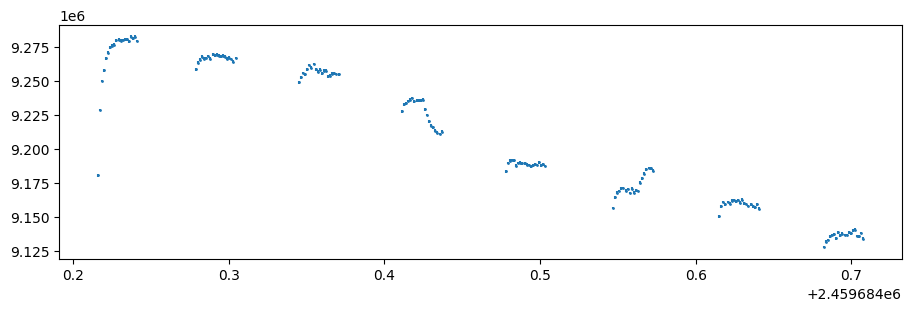

<Figure size 640x480 with 0 Axes>

In [2]:
visit = 'S22'
orbits_to_exclude = np.array([0,2,7])

speclc_bin_edges = ([
    0.799213,
    0.807118,
    0.815023,
    0.822928,
    0.878263,
    0.891438,
    0.898026,
    0.917788,
    0.925581,
    0.940567,
    0.948160,
    0.970939,
    0.978532,
    0.986125,
    1.012701,
    1.021560,
    1.039277,
    1.046870,
    1.054463,
    1.062056,
    1.068805,
    1.102552,
    1.109301,
    1.116051,
    1.1304
    ])*u.micron

speclc_err_factor = 10**np.array([
    0.00,
    0.00,
    0.00,
    0.0, # 0.12,
    0.00,
    0.00,
    0,#0.11,
    0.00,
    0.00,
    0.00,
    0,#0.06,
    0,#0.06,
    0.00,
    0,#0.09,
    0,#0.08,
    0.00,
    0.00,
    0.00,
    0,#0.08,
    0.00,
    0,#0.10,
    0.00,
    0.00,
    0,#0.10
    ])

predicted_T0 = visits[f'{visit}']['T0 (BJD_TDB)'].value
binwidth = visits[f'{visit}']['native resolution']
exptime = visits[f'{visit}']['exp (s)']
grism = visits[f'{visit}']['Grism']
_rainbow = read_rainbow(f"../../data/rainbows/{visit}_scan-combined_trimmed_pacman_spec.rainbow.npy")
rainbow = _rainbow

speclc_rainbow = rainbow.bin(wavelength_edges = speclc_bin_edges)
for i in range(len(speclc_rainbow.wavelength)):
    speclc_rainbow.uncertainty[i,:] = speclc_rainbow.uncertainty[i,:] * speclc_err_factor[i]

# Check a light curve to verify the spots are getting trimmed
plt.figure(figsize=(9,3))
plt.errorbar(speclc_rainbow.time,speclc_rainbow.flux[10,:],speclc_rainbow.uncertainty[10,:],
            fmt='o',ms=1)
plt.show()
plt.clf()

Median relative photon uncertainty at 0.8032 micron = 374ppm
Median relative photon uncertainty at 0.8111 micron = 348ppm
Median relative photon uncertainty at 0.8190 micron = 329ppm
Median relative photon uncertainty at 0.8506 micron = 102ppm
Median relative photon uncertainty at 0.8849 micron = 177ppm
Median relative photon uncertainty at 0.8947 micron = 241ppm
Median relative photon uncertainty at 0.9079 micron = 133ppm
Median relative photon uncertainty at 0.9217 micron = 202ppm
Median relative photon uncertainty at 0.9331 micron = 142ppm
Median relative photon uncertainty at 0.9444 micron = 195ppm
Median relative photon uncertainty at 0.9595 micron = 109ppm
Median relative photon uncertainty at 0.9747 micron = 185ppm
Median relative photon uncertainty at 0.9823 micron = 183ppm
Median relative photon uncertainty at 0.9994 micron = 97ppm
Median relative photon uncertainty at 1.0171 micron = 165ppm
Median relative photon uncertainty at 1.0304 micron = 114ppm
Median relative photon un

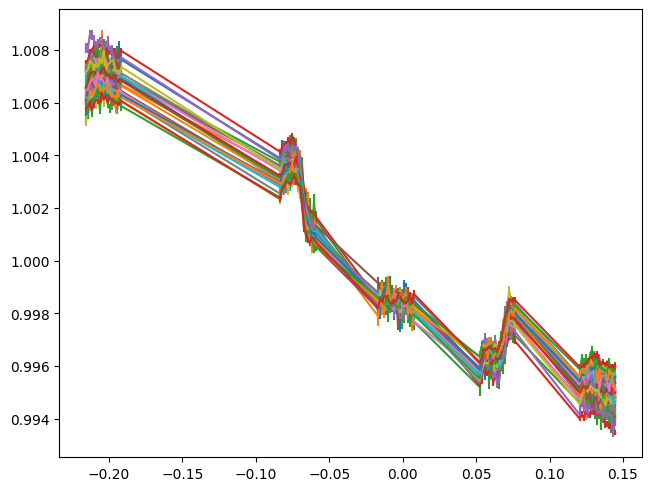

In [3]:
data_wavelengths = speclc_rainbow.wavelength.value
img_date = speclc_rainbow.time.value
data_flux = speclc_rainbow.flux.value
relative_err = speclc_rainbow.uncertainty.value/data_flux
time_from_T0 = img_date - predicted_T0
for i in range(len(data_wavelengths)):
    print(f'Median relative photon uncertainty at {data_wavelengths[i]:.4f} micron = {int(np.nanmedian(relative_err[i,:])*1e6)}ppm')

_w, _s, _e = read_sensitivity_curve(grism=grism)
binned_filter_response = bintogrid(_w.value, _s.value, newx=data_wavelengths)['y'] * u.cm**2 / u.erg

for i,date in enumerate(img_date):
    e_per_s = data_flux[:,i] / exptime
    e_per_s_per_angstrom = e_per_s / binwidth
    calibrated_flux = (e_per_s_per_angstrom.flatten() / binned_filter_response)
    data_flux[:,i] = calibrated_flux.value

# Label the orbits
orbit = np.zeros_like(img_date)
for j in range(len(img_date)):
    if j >= 1:
        if (img_date[j] - img_date[j - 1]) > 0.01:
            orbit[j] = (orbit[j - 1] + 1)
        else:
            orbit[j] = orbit[j - 1]

# Trim the first point from each orbit
ref_time = []
for o in np.unique(orbit):
    first_index = np.where(orbit == o)[0][0]
    ref_time.append(img_date[first_index])
    data_flux[:, first_index] = np.nan  # Set the first point of each subsequent orbit to np.nan
    relative_err[:, first_index] = np.nan
    img_date[first_index] = np.nan
    time_from_T0[first_index] = np.nan

# Set data to nan if it was in the pre-defined list of orbits to exclude
for orbit_to_exclude in orbits_to_exclude:
    data_flux[:, orbit == orbit_to_exclude] = np.nan
    relative_err[:, orbit == orbit_to_exclude] = np.nan
    img_date[orbit == orbit_to_exclude] = np.nan
    time_from_T0[orbit == orbit_to_exclude] = np.nan

# Populate ramp_phase time arrays
phase_list=[]
for o in [0,1,2,3,4,5,6,7]:
    rphase = (img_date[orbit==o] - ref_time[o]) / 0.066
    phase_list.append(rphase)
ramp_phase = np.concatenate(phase_list)
breathing_phase = ( (img_date-ref_time[0]+0.02) / 0.066 ) % 1

# Convert all arrays to JAX arrays
data_flux = jnp.array( data_flux[:,~np.isnan(time_from_T0)] )
_relative_err = jnp.array(relative_err[:,~np.isnan(time_from_T0)] )
img_date = jnp.array(img_date[~np.isnan(time_from_T0)] )
time_from_T0 = jnp.array(time_from_T0[~np.isnan(time_from_T0)] )
ramp_phase = jnp.array(ramp_phase[~np.isnan(ramp_phase)] )
breathing_phase = jnp.array(breathing_phase[~np.isnan(breathing_phase)] )

mean_per_wavelength = jnp.mean(data_flux, axis=1, keepdims=True)
normalized_data_flux = data_flux / mean_per_wavelength
relative_err = _relative_err * normalized_data_flux

planet_parameters = dict(
    inclination = np.radians(89.5),
    a = 19.2,
    rp = 0.042,
    period = 8.46,
    t0 = 0,
    ecc = 0.0,
    u1 = 0.25,
    u2 = 0.15)

# Corrected latitude generation - choose distribution for each spot
# choice_indices = np.random.choice([0, 1], size=800)
# dist1 = np.random.beta(2, 1, n_spots) * (1.2 - 0.3) + 0.3
# dist2 = np.random.beta(1, 2, n_spots) * (3.0 - 2.0) + 2.0
# initial_lats = jnp.array(np.where(choice_indices == 0, dist1, dist2))

for i in range(len(data_wavelengths)):
    plt.errorbar(time_from_T0, normalized_data_flux[i,:], relative_err[i,:])

In [4]:
def read_spots_file_to_jax(filename):
    """
    Read spot coordinates from a file and return as JAX arrays.
    
    Parameters:
    - filename: input filename
    
    Returns:
    - latitudes, longitudes as JAX arrays
    - metadata dictionary
    """
    latitudes = []
    longitudes = []
    
    with open(filename, 'r') as f:
        for line in f:
            line = line.strip()
            
            if not line or line.startswith('#'):
                if line.startswith('#') and ':' in line:
                    key_value = line[1:].split(':', 1)
                    if len(key_value) == 2:
                        key = key_value[0].strip()
                        value = key_value[1].strip()
                continue
            
            parts = line.split()
            if len(parts) >= 2:
                try:
                    lat = float(parts[0])
                    lon = float(parts[1])
                    latitudes.append(lat)
                    longitudes.append(lon)
                except ValueError:
                    continue
    
    # Convert to JAX arrays
    latitudes_jax = jnp.array(latitudes)
    longitudes_jax = jnp.array(longitudes)
    
    return latitudes_jax, longitudes_jax

spot_latitudes, spot_longitudes = read_spots_file_to_jax('band_spots.txt')
n_spots = spot_latitudes.size

In [5]:
default_params={

    # Ramp Model Parameters
    'r_1': 3.88,
    'r_2': -4.976,
    'r_3': 0, #0.0135,
    #Breathing params
    'b_1':0.060, # 0.060 +/- ????
    'b_2':-0.247, # -0.247 +/- 0.010
    'b_3':0.343, # 0.343 +/- 0.009
    'b_4':-0.1640, # -0.1640 +/- 0.0006
    'slope':0,
    
    # Planet parameters
    'Mp':20.0,
    'i_planet':89.5,
    'P_orb':8.463,
    't_0':0.00056,
    'rp_rstar': 0.04874,
    'a_rstar': 19.2,
    'ecc': 0.0,
    'u_1':0.35,
    'u1_slope':0,
    'u1_intercept':0,
    'u_2':0.15,
    'u2_slope':0,
    'u2_intercept':0,
    
    # Stellar parameters
    'log_g':4.5,
    'i_star':89.5,
    'P_rot':4.86,
    'Rs':0.8,
    'Ms':0.6,
    'metallicity':0.0,

    # Spot Parameters
    # 'log_fixedspot_radii':-2.0,
    # 'T_unocculted': 3100,
    'T_phot': 3891,
    'T_occulted': 3020,
    'limb_spot_lon':-1.299,
    'limb_spot_lat':0.8,
    'limb_spot_rad':0.22,
    'chord_spot_lon_1':0.057,
    'chord_spot_lat_1':1.65,
    'chord_spot_rad_1':0.0685,
    'chord_spot_lon_2':0.861,
    'chord_spot_lat_2':1.66,
    'chord_spot_rad_2':0.055,

    # Model meta-parameters
    'beta':0.105,

}

In [12]:
def numpyro_model():

    """
    Define the probabilistic model in NUMPYRO
    """
    params = {}

    # Instrument Parameters
    params['r_1'] = default_params['r_1']
    params['r_2'] = default_params['r_2']
    params['r_3'] = default_params['r_3']

    # Instrument Parameters
    params['b_1'] = default_params['b_1']
    params['b_2'] = default_params['b_2']
    params['b_3'] = default_params['b_3']
    params['b_4'] = default_params['b_4']

    # Baseline Parameters
        
    params['limb_spot_lon'] = numpyro.sample('limb_spot_lon', dist.Uniform(-1.4, -1.3))
    params['limb_spot_lat'] = 0.8 #numpyro.sample('limb_spot_lat', dist.Uniform(0.5, 1.4))
    params['limb_spot_rad'] = numpyro.sample('limb_spot_rad', dist.Uniform(0.2, 0.4))
    
    params['chord_spot_lon_1'] = 0.057#numpyro.sample('chord_spot_lon_1', dist.Uniform(0.03, 0.1))
    params['chord_spot_lat_1'] = numpyro.sample('chord_spot_lat_1', dist.Uniform(1.45, 1.65))
    params['chord_spot_rad_1'] = numpyro.sample('chord_spot_rad_1', dist.Uniform(0.1, 0.22))

    params['chord_spot_lon_2'] = 0.861#numpyro.sample('chord_spot_lon_2', dist.Uniform(0.84,0.88))
    params['chord_spot_lat_2'] = numpyro.sample('chord_spot_lat_2', dist.Uniform(1.745, 1.84))
    params['chord_spot_rad_2'] = numpyro.sample('chord_spot_rad_2', dist.Uniform(0.03, 0.1))

    # Planet Parameters
    params['rp_rstar'] = numpyro.sample('rp_rstar', dist.Uniform(0.044, 0.050),sample_shape=data_wavelengths.shape)
    params['t_0'] = 0.00056 #numpyro.sample('t_0', dist.Uniform(0.00032, 0.00072))
    params['a_rstar'] = numpyro.sample('a_rstar', dist.Uniform(19.1, 19.3))
    
    # u1_intercept = numpyro.sample('u1_intercept', dist.Uniform(0.1,0.4))
    # u1_slope = numpyro.sample('u1_slope', dist.Uniform(-0.45,0.45))
    # params['u_1'] = numpyro.deterministic('u_1', (u1_slope*(data_wavelengths-data_wavelengths[0]) + u1_intercept) )
    params['u_1'] = numpyro.sample('u_1', dist.Uniform(0.0, 0.5),sample_shape=data_wavelengths.shape)
    params['u_2'] = numpyro.sample('u_2', dist.Uniform(0.0, 0.5),sample_shape=data_wavelengths.shape)

    # u2_intercept = numpyro.sample('u2_intercept', dist.Uniform(0.0,0.5))
    # u2_slope = numpyro.sample('u2_slope', dist.Uniform(-0.5,1.0))
    # params['u_2'] = numpyro.deterministic('u_2', (u2_slope*(data_wavelengths-data_wavelengths[0]) + u2_intercept) )
    
    # Stellar Parameters
    params['T_phot'] = 3891 #numpyro.sample('T_phot', dist.TruncatedNormal(loc=3891, scale=37,low=3650,high=4200))
    # delta_T = numpyro.sample('delta_T', dist.Uniform(-1200, 0))
    params['T_occulted'] = numpyro.sample('T_occulted', dist.TruncatedNormal(loc=3020, scale=69,low=2600,high=3400))
    # params['T_unocculted'] = numpyro.sample('T_unocculted', dist.Uniform(2800, 3600))
    # params['log_fixedspot_radii'] = numpyro.sample('log_fixedspot_radii', dist.Uniform(-3.5, -1))
    
    err_inflation = numpyro.sample('beta', dist.Uniform(1.0, 5.0),sample_shape=data_wavelengths.shape)

    @jit
    def spectroscopic_transit(params,**kwargs):

        # Calculate systematics model
        ramp = ramp_model_jax(phase=ramp_phase,
                        r1=jnp.asarray(params['r_1'], dtype=jnp.float64),
                        r2=jnp.asarray(params['r_2'], dtype=jnp.float64),
                        r3=jnp.asarray(params['r_3'], dtype=jnp.float64) )
        breathing = breathing_model_jax(phase=breathing_phase,
                                  b1=jnp.asarray(params['b_1'], dtype=jnp.float64),
                                  b2=jnp.asarray(params['b_2'], dtype=jnp.float64),
                                  b3=jnp.asarray(params['b_3'], dtype=jnp.float64),
                                  b4=jnp.asarray(params['b_4'], dtype=jnp.float64))
        _systematics = (breathing * ramp)
        systematics = _systematics/jnp.mean(_systematics)
        sys_2d = systematics[jnp.newaxis, :]
        
        # Update Planet Parameters
        planet_parameters = dict(
            inclination = jnp.radians(default_params['i_planet']),
            a = jnp.asarray(params['a_rstar'], dtype=jnp.float64),
            rp = jnp.asarray(params['rp_rstar'], dtype=jnp.float64),
            period = default_params['P_orb'],
            t0 = jnp.asarray(params['t_0'], dtype=jnp.float64),
            ecc = default_params['ecc'],
            u1 = jnp.asarray(params['u_1'], dtype=jnp.float64),
            u2 = jnp.asarray(params['u_2'], dtype=jnp.float64)
        )
        
        # Get spectra for the model temps
        Cool_occulted, Phot = [
            get_BTSettl_spectrum_jax(T=Temp,metallicity=0,data_wave = data_wavelengths)
            for Temp in [jnp.asarray(params['T_occulted'], dtype=jnp.float64),
                        # jnp.asarray(params['T_unocculted'], dtype=jnp.float64),
                        jnp.asarray(params['T_phot'], dtype=jnp.float64)] ]
        
        # Update stellar parameters
        active_star = ActiveStar(
            times = time_from_T0,
            inclination=jnp.radians(default_params['i_star']),
            T_eff=jnp.asarray(params['T_phot'], dtype=jnp.float64),
            wavelength=Phot[0]*1e-6, # convert from micron to m
            phot=Phot[1],
            P_rot=default_params['P_rot']
        )
        
        active_star.spectrum = jnp.concatenate([
            jnp.vstack([Cool_occulted[1],Cool_occulted[1],Cool_occulted[1]]),
            # jnp.vstack([Cool_unocculted[1]]*n_spots)
        ])
        active_star.temperature = jnp.concatenate([
            jnp.array([params['T_occulted'], params['T_occulted'], params['T_occulted']]),
            # jnp.array([params['T_unocculted'] * n_spots])
        ])
        active_star.rad = jnp.concatenate([
            jnp.array([params['chord_spot_rad_1'],params['chord_spot_rad_2'],params['limb_spot_rad']]),
            # jnp.array([10**(jnp.array(params['log_fixedspot_radii']))] * n_spots)
        ])
        active_star.lon = jnp.concatenate([
            jnp.array([params['chord_spot_lon_1'],params['chord_spot_lon_2'],params['limb_spot_lon']]),
            # spot_longitudes
        ])
        active_star.lat = jnp.concatenate([
            jnp.array([params['chord_spot_lat_1'],params['chord_spot_lat_2'],params['limb_spot_lat']]),
            # spot_latitudes
        ])
        
        lc, contam, X, Y, spectrum_at_transit = active_star.transit_model(**planet_parameters)        
        lc_model = lc.T * sys_2d
        mean_per_wavelength = jnp.mean(lc_model, axis=1, keepdims=True)
        normalized_model = lc_model / mean_per_wavelength
    
        return normalized_model

    numpyro.sample(
        'Obs', dist.Normal(
            loc=spectroscopic_transit(params), 
            scale=relative_err*err_inflation[:,None],
        ), obs=normalized_data_flux
    )

In [13]:
def plot_results(parameter_dict,
                 samples=None,
                 figlabel='missinglabel',
                 n_free_parameters=None):
    """
    Plot multi-wavelength transit light curves after removing systematics
    and stellar rotation. Shows fully detrended (transit-only) light curves
    and residuals, both vertically offset for clarity.

    Also produces additional figures:
    - Contamination and transmission spectra
    - Stellar maps for each wavelength (limb‑darkening varies)
    - Full‑range light curves (no star map) showing the entire time axis

    Parameters
    ----------
    parameter_dict : dict
        Parameter values (MAP or MLE). Must include all required keys.
    samples : dict or None
        If provided, a dictionary of posterior samples with shape (n_samples, ...)
        for each parameter. The function will compute model predictions for a
        random subset of these samples and plot median ± 68% credible interval.
        The `parameter_dict` is assumed to be the MLE set.
    figlabel : str
        Suffix for saved figure filenames.
    n_free_parameters : int, optional
        If provided, overrides the total DoF calculation.
    """
    params = parameter_dict

    # ------------------------------------------------------------------
    # Helper: compute everything for a single parameter set
    # ------------------------------------------------------------------
    def compute_model_for_params(p):
        """Return (data_detrended, model_detrended, err_detrended,
                   contam_spectrum, wl_micron, rp_vals, star, normalized_model,
                   contrast_spectrum)."""
        # Systematics
        ramp = ramp_model_jax(phase=ramp_phase,
                              r1=p.get('r_1', default_params['r_1']),
                              r2=p.get('r_2', default_params['r_2']),
                              r3=p.get('r_3', default_params['r_3']))
        breathing = breathing_model_jax(phase=breathing_phase,
                                        b1=p.get('b_1', default_params['b_1']),
                                        b2=p.get('b_2', default_params['b_2']),
                                        b3=p.get('b_3', default_params['b_3']),
                                        b4=p.get('b_4', default_params['b_4']))
        _systematics = breathing * ramp
        systematics = _systematics / jnp.mean(_systematics)
        sys_2d = systematics[jnp.newaxis, :]

        # Limb darkening
        if 'u1_slope' in p and 'u1_intercept' in p:
            u1 = p['u1_slope'] * (data_wavelengths - data_wavelengths[0]) + p['u1_intercept']
            u2 = p['u2_slope'] * (data_wavelengths - data_wavelengths[0]) + p['u2_intercept']
        else:
            u1 = p.get('u_1', default_params['u_1'])
            u2 = p.get('u_2', default_params['u_2'])

        # Planet parameters
        rp_vals = np.asarray(p.get('rp_rstar', default_params['rp_rstar'])).ravel()
        planet_params = {
            'inclination': jnp.radians(default_params['i_planet']),
            'a': jnp.asarray(p.get('a_rstar', default_params['a_rstar']), dtype=jnp.float64),
            'rp': jnp.asarray(rp_vals, dtype=jnp.float64),
            'period': jnp.asarray(default_params['P_orb'], dtype=jnp.float64),
            't0': jnp.asarray(p.get('t_0', default_params['t_0']), dtype=jnp.float64),
            'ecc': jnp.asarray(default_params['ecc'], dtype=jnp.float64),
            'u1': jnp.asarray(u1, dtype=jnp.float64),
            'u2': jnp.asarray(u2, dtype=jnp.float64),
        }
        no_planet_params = planet_params.copy()
        no_planet_params['rp'] = 0.0

        # Spectra and star
        T_occ = p.get('T_occulted', default_params['T_occulted'])
        T_ph = p.get('T_phot', default_params['T_phot'])
        Cool_occ, Phot = [
            get_BTSettl_spectrum_jax(T=jnp.asarray(Temp, dtype=jnp.float64), metallicity=0,
                                     data_wave=data_wavelengths)
            for Temp in [T_occ, T_ph]
        ]

        # Compute contrast: 1 - F_spot/F_phot
        contrast = 1 - (Cool_occ[1] / Phot[1])   # array of length n_wavelengths
        star = ActiveStar(
            times=time_from_T0,
            inclination=jnp.radians(default_params['i_star']),
            T_eff=jnp.asarray(T_ph, dtype=jnp.float64),
            wavelength=Phot[0] * 1e-6,
            phot=Phot[1],
            P_rot=default_params['P_rot']
        )
        star.spectrum = jnp.vstack([Cool_occ[1]] * 3)
        star.temperature = jnp.array([T_occ] * 3)
        star.rad = jnp.array([
            p.get('chord_spot_rad_1', default_params['chord_spot_rad_1']),
            p.get('chord_spot_rad_2', default_params['chord_spot_rad_2']),
            p.get('limb_spot_rad', default_params['limb_spot_rad'])
        ])
        star.lon = jnp.array([
            p.get('chord_spot_lon_1', default_params['chord_spot_lon_1']),
            p.get('chord_spot_lon_2', default_params['chord_spot_lon_2']),
            p.get('limb_spot_lon', default_params['limb_spot_lon'])
        ])
        star.lat = jnp.array([
            p.get('chord_spot_lat_1', default_params['chord_spot_lat_1']),
            p.get('chord_spot_lat_2', default_params['chord_spot_lat_2']),
            p.get('limb_spot_lat', default_params['limb_spot_lat'])
        ])

        # Transit models
        lc, contam, _, _, _ = star.transit_model(**planet_params)
        lc_no_planet, _, _, _, _ = star.transit_model(**no_planet_params)

        transit_with_rot = lc.T
        mean_flux = jnp.mean(transit_with_rot, axis=1, keepdims=True)
        transit_with_rot = transit_with_rot / mean_flux

        rot_model = lc_no_planet.T
        mean_rot = jnp.mean(rot_model, axis=1, keepdims=True)
        rot_curve = rot_model / mean_rot

        model_detrended = transit_with_rot / rot_curve

        full_model = transit_with_rot * sys_2d
        normalized_model = full_model / jnp.mean(full_model, axis=1, keepdims=True)

        data_detrended = normalized_data_flux / (rot_curve * sys_2d)
        data_detrended /= jnp.mean(data_detrended, axis=1, keepdims=True)
        err_detrended = relative_err / (rot_curve * sys_2d)

        # Contamination spectrum (average over time)
        contam_spectrum = np.mean(contam, axis=0) if contam.ndim == 2 else contam
        wl_micron = np.asarray(star.wavelength * 1e6)

        return (data_detrended, model_detrended, err_detrended,
                contam_spectrum, wl_micron, rp_vals, star, normalized_model,
                np.asarray(contrast))

    # ------------------------------------------------------------------
    # Single parameter set (original behaviour)
    # ------------------------------------------------------------------
    if samples is None or samples is False:
        (data_det, model_det, err_det, contam_spec,
         wl_micron, rp_vals, star, normalized_model, contrasts) = compute_model_for_params(params)

        # Convert to numpy arrays for consistency
        data_det = np.asarray(data_det)
        model_det = np.asarray(model_det)
        err_det = np.asarray(err_det)
        contam_spec = np.asarray(contam_spec)
        wl_micron = np.asarray(wl_micron)
        rp_vals = np.asarray(rp_vals)

        # Limb-darkening arrays for per‑wavelength maps
        if 'u1_slope' in params and 'u1_intercept' in params:
            u1_arr = params['u1_slope'] * (data_wavelengths - data_wavelengths[0]) + params['u1_intercept']
            u2_arr = params['u2_slope'] * (data_wavelengths - data_wavelengths[0]) + params['u2_intercept']
        else:
            u1_arr = params.get('u_1', default_params['u_1'])
            u2_arr = params.get('u_2', default_params['u_2'])
        u1_arr = np.asarray(u1_arr).ravel()
        u2_arr = np.asarray(u2_arr).ravel()

        # ---- Chi‑squared with new DoF definitions ----
        n_wavelengths = len(data_wavelengths)
        n_times = data_det.shape[1]
        per_wavelength_dof = n_times - 12   # user‑specified DoF per wavelength
        total_dof = n_wavelengths * n_times - (9 + 3*n_wavelengths)

        chi2_per_wavelength = []
        reduced_chi2_per_wavelength = []
        for i in range(n_wavelengths):
            resid = data_det[i, :] - model_det[i, :]
            err = err_det[i, :]
            mask = err > 0
            ndata = np.sum(mask)
            chi2 = np.sum((resid[mask] / err[mask]) ** 2)
            dof = ndata - 13
            if dof <= 0:
                dof = 1
            reduced_chi2 = chi2 / dof
            chi2_per_wavelength.append(chi2)
            reduced_chi2_per_wavelength.append(reduced_chi2)

        total_chi2 = sum(chi2_per_wavelength)
        if n_free_parameters is not None:
            total_dof = n_wavelengths * n_times - n_free_parameters
        else:
            total_dof = n_wavelengths * n_times - (9 + 3*n_wavelengths)
        total_reduced_chi2 = total_chi2 / total_dof if total_dof > 0 else np.nan

        print("\nChi-squared statistics:")
        for i, wl in enumerate(data_wavelengths):
            print(f"  Wavelength {wl:.4f} µm: chi2 = {chi2_per_wavelength[i]:.2f}, reduced chi2 = {reduced_chi2_per_wavelength[i]:.2f} (DoF = {n_times - 13:.0f})")
        print(f"Total chi2 = {total_chi2:.2f}, total reduced chi2 = {total_reduced_chi2:.2f} (DoF = {total_dof})")

        # ---- Vertical offsets ----
        data_std = np.std(data_det)
        offset_scale = 1.1 * data_std if data_std > 1e-6 else 0.005
        res_offset_scale = offset_scale * 0.5
        wavelengths = np.asarray(data_wavelengths)

        # ---- Main figure (light curves + residuals) with star map ----
        fig = plt.figure(figsize=(14, 8), constrained_layout=True)
        gs = fig.add_gridspec(2, 2, width_ratios=[1, 1], height_ratios=[1, 1])   # wider star panel

        ax_star = fig.add_subplot(gs[:, 0])
        u1_plot = float(np.median(u1_arr)) if u1_arr.size > 1 else float(u1_arr[0])
        u2_plot = float(np.median(u2_arr)) if u2_arr.size > 1 else float(u2_arr[0])
        contrast_scalar = float(np.median(contrasts))  # scalar for main map
        star.plot_star(
            t0=params.get('t_0', default_params['t_0']),
            rp=rp_vals if rp_vals.size > 1 else rp_vals[0],
            a=params.get('a_rstar', default_params['a_rstar']),
            inclination=np.radians(89.5),
            ecc=default_params['ecc'],
            u1=u1_plot,
            u2=u2_plot,
            spot_contrast=contrast_scalar,
            ax=ax_star
        )
        ax_star.set_facecolor('black')

        ax_mid = fig.add_subplot(gs[0, 1])
        norm = mcolors.Normalize(vmin=wavelengths.min(), vmax=wavelengths.max())
        cmap = plt.cm.viridis

        for i, wl in enumerate(wavelengths):
            color = cmap(norm(wl))
            offset = i * offset_scale
            ax_mid.errorbar(time_from_T0, data_det[i, :] + offset,
                            yerr=err_det[i, :],
                            fmt='o', ms=2, color=color, alpha=0.6,
                            label=f'{wl:.2f} µm' if i % 2 == 0 else "")
            ax_mid.plot(time_from_T0, model_det[i, :] + offset,
                        'k-', lw=1.2, alpha=0.7)

        ax_mid.set_ylabel('Detrended Flux + offset')
        ax_mid.set_title('Transit Only (Systematics & Rotation removed)')
        ax_mid.set_xlim(-0.08, 0.08)   # restrict to transit
        # ax_mid.grid(alpha=0.3)

        sm = ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax_mid, orientation='vertical', pad=0.02)
        cbar.set_label('Wavelength (µm)')

        ax_res = fig.add_subplot(gs[1, 1], sharex=ax_mid)
        for i, wl in enumerate(wavelengths):
            color = cmap(norm(wl))
            # offset = i * res_offset_scale
            offset = 0
            residuals = (data_det[i, :] - model_det[i, :]) * 1e6
            ax_res.errorbar(time_from_T0, residuals + offset,
                            yerr=err_det[i, :] * 1e6,
                            fmt='o', ms=2, color=color, alpha=0.6)
            ax_res.axhline(y=0 + offset, color=color, linestyle='--', alpha=0.3, linewidth=0.8)

        ax_res.axhline(y=0, color='k', linestyle='-', alpha=0.5)
        ax_res.set_ylabel('Residuals (ppm) + offset')
        ax_res.set_xlabel('Time from T0')
        ax_res.set_title('Residuals (Data – Transit Model)')
        ax_res.grid(alpha=0.3)

        textstr = f"Total χ² = {total_chi2:.2f}\nχ²_red = {total_reduced_chi2:.2f} (DoF={total_dof})"
        ax_res.text(0.98, 0.98, textstr,
                    transform=ax_res.transAxes,
                    fontsize=10, verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

        plt.savefig(f'../../figs/{model_designation}_{figlabel}.png', dpi=400)
        plt.show()
        plt.clf()

        # ---- Additional figure: full-range light curves (no star) ----
        fig_full, (ax_full, ax_res_full) = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                                                        constrained_layout=True)
        for i, wl in enumerate(wavelengths):
            color = cmap(norm(wl))
            offset = i * offset_scale
            ax_full.errorbar(time_from_T0, data_det[i, :] + offset,
                             yerr=err_det[i, :],
                             fmt='o', ms=2, color=color, alpha=0.6,
                             label=f'{wl:.2f} µm' if i % 2 == 0 else "")
            ax_full.plot(time_from_T0, model_det[i, :] + offset,
                         'k-', lw=1.2, alpha=0.7)

        ax_full.set_ylabel('Detrended Flux + offset')
        ax_full.set_title('Full‑range Light Curves (no star map)')
        ax_full.grid(alpha=0.3)
        # No xlim restriction – full range

        for i, wl in enumerate(wavelengths):
            color = cmap(norm(wl))
            # offset = i * res_offset_scale
            offset = 0
            residuals = (data_det[i, :] - model_det[i, :]) * 1e6
            ax_res_full.errorbar(time_from_T0, residuals + offset,
                                 yerr=err_det[i, :] * 1e6,
                                 fmt='o', ms=2, color=color, alpha=0.6)
            ax_res_full.axhline(y=0 + offset, color=color, linestyle='--', alpha=0.3, linewidth=0.8)

        ax_res_full.axhline(y=0, color='k', linestyle='-', alpha=0.5)
        ax_res_full.set_ylabel('Residuals (ppm) + offset')
        ax_res_full.set_xlabel('Time from T0')
        ax_res_full.set_title('Residuals (Data – Transit Model) – Full Range')
        ax_res_full.grid(alpha=0.3)

        plt.savefig(f'../../figs/{model_designation}_{figlabel}_fullrange.png', dpi=400)
        plt.show()
        plt.clf()

        # ---- Spectra figure (single sample) ----
        fig2, axs = plt.subplots(3, 1, figsize=(6, 6), sharex=True)

        axs[0].scatter(wl_micron, contam_spec * 1e6, s=10, color='k')
        axs[0].set_ylabel('Depth (ppm)')
        axs[0].set_title('Contaminated Transmission Spectrum')

        axs[1].scatter(wl_micron, (contam_spec - rp_vals**2) * 1e6, s=10, color='k')
        axs[1].set_ylabel('Depth (ppm)')
        axs[1].set_title('Contamination Only')

        axs[2].scatter(wl_micron, rp_vals**2 * 1e6, s=10, color='k')
        axs[2].set_ylabel('Transit Depth (ppm)')
        axs[2].set_title('De‑contaminated Transmission Spectrum')
        axs[2].set_xlabel(r'Wavelength ($\mu$m)')

        fig2.tight_layout()
        plt.savefig(f'../../figs/{model_designation}_{figlabel}_spectra.png', dpi=400)
        plt.show()
        plt.clf()

        # ---- Stellar maps per wavelength (single sample) ----
        n_wl = len(wl_micron)
        n_cols = 4
        n_rows = int(np.ceil(n_wl / n_cols))
        fig3, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows),
                                  constrained_layout=True)
        if n_rows == 1 and n_cols == 1:
            axes_flat = [axes]
        else:
            axes_flat = axes.flatten()

        for i in range(n_wl):
            ax = axes_flat[i]
            u1_wl = float(u1_arr[i]) if u1_arr.size > 1 else float(u1_arr[0])
            u2_wl = float(u2_arr[i]) if u2_arr.size > 1 else float(u2_arr[0])
            star.plot_star(
                t0=params.get('t_0', default_params['t_0']),
                rp=rp_vals if rp_vals.size > 1 else rp_vals[0],
                a=params.get('a_rstar', default_params['a_rstar']),
                inclination=np.radians(89.5),
                ecc=default_params['ecc'],
                u1=u1_wl,
                u2=u2_wl,
                spot_contrast=contrasts[i],   # per‑wavelength contrast
                ax=ax
            )
            ax.set_facecolor('black')
            ax.text(0.05, 0.95, f'{wl_micron[i]:.3f} µm',
                    transform=ax.transAxes, fontsize=10,
                    verticalalignment='top', color='white',
                    bbox=dict(boxstyle='round', facecolor='black', alpha=0.6))

        for j in range(i + 1, len(axes_flat)):
            axes_flat[j].axis('off')

        fig3.suptitle('Stellar Maps per Wavelength', fontsize=14)
        plt.savefig(f'../../figs/{model_designation}_{figlabel}_stellar_maps.png', dpi=400)
        plt.show()
        plt.clf()

        return normalized_model, star

    # ------------------------------------------------------------------
    # Multi‑sample case (posterior predictive)
    # ------------------------------------------------------------------
    else:
        # ---- Print parameter statistics (median ±1σ and MLE) ----
        print("\nParameter statistics (median ±1σ and MLE):")
        for param_name in samples.keys():
            flat = samples[param_name].flatten()
            med = np.percentile(flat, 50)
            low = np.percentile(flat, 16)
            high = np.percentile(flat, 84)
            mle_val = params.get(param_name, np.nan)
            print(f"  {param_name}: median = {med:.6f}  [{low:.6f}, {high:.6f}]  MLE = {mle_val:.6f}")

        # ---- Compute MLE model for chi‑squared ----
        (data_det_mle, model_det_mle, err_det_mle,
         contam_spec_mle, wl_micron_mle, rp_vals_mle,
         star_mle, normalized_model_mle, contrasts_mle) = compute_model_for_params(params)

        data_det_mle = np.asarray(data_det_mle)
        model_det_mle = np.asarray(model_det_mle)
        err_det_mle = np.asarray(err_det_mle)
        wl_micron = np.asarray(wl_micron_mle)
        rp_vals = np.asarray(rp_vals_mle)

        # ---- Chi‑squared from MLE model ----
        n_wavelengths = len(data_wavelengths)
        n_times = data_det_mle.shape[1]
        chi2_per_wavelength = []
        reduced_chi2_per_wavelength = []
        for i in range(n_wavelengths):
            resid = data_det_mle[i, :] - model_det_mle[i, :]
            err = err_det_mle[i, :]
            mask = err > 0
            ndata = np.sum(mask)
            chi2 = np.sum((resid[mask] / err[mask]) ** 2)
            dof = ndata - 13
            if dof <= 0:
                dof = 1
            reduced_chi2 = chi2 / dof
            chi2_per_wavelength.append(chi2)
            reduced_chi2_per_wavelength.append(reduced_chi2)

        total_chi2 = sum(chi2_per_wavelength)
        if n_free_parameters is not None:
            total_dof = n_wavelengths * n_times - n_free_parameters
        else:
            total_dof = n_wavelengths * n_times - (12 + n_wavelengths)
        total_reduced_chi2 = total_chi2 / total_dof if total_dof > 0 else np.nan

        print("\nMLE chi-squared statistics:")
        for i, wl in enumerate(data_wavelengths):
            print(f"  Wavelength {wl:.4f} µm: chi2 = {chi2_per_wavelength[i]:.2f}, reduced chi2 = {reduced_chi2_per_wavelength[i]:.2f} (DoF = {n_times - 13:.0f})")
        print(f"Total chi2 = {total_chi2:.2f}, total reduced chi2 = {total_reduced_chi2:.2f} (DoF = {total_dof})")

        # ---- Proceed with posterior predictive plots (uncertainty bands) ----
        import random
        n_samples_total = len(samples[list(samples.keys())[0]])
        n_use = min(200, n_samples_total)
        indices = random.sample(range(n_samples_total), n_use)

        all_data_det = []
        all_model_det = []
        all_err_det = []
        all_contam = []
        all_rp = []
        all_contrast = []

        for idx in indices:
            p = {k: samples[k][idx] for k in samples.keys()}
            for k in default_params:
                if k not in p:
                    p[k] = default_params[k]
            dd, md, ed, cs, wl, rp, _, _, cont = compute_model_for_params(p)
            all_data_det.append(dd)
            all_model_det.append(md)
            all_err_det.append(ed)
            all_contam.append(cs)
            all_rp.append(rp)
            all_contrast.append(cont)

        data_stack = np.stack(all_data_det, axis=0)
        model_stack = np.stack(all_model_det, axis=0)
        err_stack = np.stack(all_err_det, axis=0)
        contam_stack = np.stack(all_contam, axis=0)
        rp_stack = np.stack(all_rp, axis=0)
        contrast_stack = np.stack(all_contrast, axis=0)

        # Percentiles for data, model, residuals
        data_med = np.median(data_stack, axis=0)
        data_low = np.percentile(data_stack, 16, axis=0)
        data_high = np.percentile(data_stack, 84, axis=0)

        model_med = np.median(model_stack, axis=0)
        model_low = np.percentile(model_stack, 16, axis=0)
        model_high = np.percentile(model_stack, 84, axis=0)

        residuals_stack = data_stack - model_stack
        res_med = np.median(residuals_stack, axis=0) * 1e6
        res_low = np.percentile(residuals_stack, 16, axis=0) * 1e6
        res_high = np.percentile(residuals_stack, 84, axis=0) * 1e6

        err_med = np.median(err_stack, axis=0)

        # Spectra: contamination signal and rp² per sample
        contam_signal_stack = contam_stack - rp_stack**2
        rp2_stack = rp_stack**2

        contam_med = np.median(contam_stack, axis=0)
        contam_low = np.percentile(contam_stack, 16, axis=0)
        contam_high = np.percentile(contam_stack, 84, axis=0)

        contam_signal_med = np.median(contam_signal_stack, axis=0)
        contam_signal_low = np.percentile(contam_signal_stack, 16, axis=0)
        contam_signal_high = np.percentile(contam_signal_stack, 84, axis=0)

        rp2_med = np.median(rp2_stack, axis=0)
        rp2_low = np.percentile(rp2_stack, 16, axis=0)
        rp2_high = np.percentile(rp2_stack, 84, axis=0)

        # Median contrast for stellar maps
        contrast_med = np.median(contrast_stack, axis=0)

        wavelengths = np.asarray(data_wavelengths)
        data_std = np.std(data_med)
        offset_scale = 1.1 * data_std if data_std > 1e-6 else 0.005
        res_offset_scale = offset_scale * 0.5

        # ---- Main figure with uncertainty bands (with star map) ----
        fig = plt.figure(figsize=(14, 8), constrained_layout=True)
        gs = fig.add_gridspec(2, 2, width_ratios=[2, 1.5], height_ratios=[1, 1])

        ax_star = fig.add_subplot(gs[:, 0])
        u1_med = np.median(u1_arr) if 'u1_arr' in locals() else 0.3
        u2_med = np.median(u2_arr) if 'u2_arr' in locals() else 0.3
        star_mle.plot_star(
            t0=params.get('t_0', default_params['t_0']),
            rp=rp_vals if rp_vals.size > 1 else rp_vals[0],
            a=params.get('a_rstar', default_params['a_rstar']),
            inclination=np.radians(89.5),
            ecc=default_params['ecc'],
            u1=u1_med,
            u2=u2_med,
            spot_contrast=np.median(contrast_med),   # scalar for map
            ax=ax_star
        )
        ax_star.set_facecolor('black')

        ax_mid = fig.add_subplot(gs[0, 1])
        norm = mcolors.Normalize(vmin=wavelengths.min(), vmax=wavelengths.max())
        cmap = plt.cm.viridis

        for i, wl in enumerate(wavelengths):
            color = cmap(norm(wl))
            offset = i * offset_scale
            ax_mid.errorbar(time_from_T0, data_med[i, :] + offset,
                            yerr=None, fmt='o', ms=2, color=color, alpha=0.6,
                            label=f'{wl:.2f} µm' if i % 2 == 0 else "")
            ax_mid.fill_between(time_from_T0, data_low[i, :] + offset, data_high[i, :] + offset,
                                color=color, alpha=0.2)
            ax_mid.plot(time_from_T0, model_med[i, :] + offset, 'k-', lw=1.2, alpha=0.7)
            ax_mid.fill_between(time_from_T0, model_low[i, :] + offset, model_high[i, :] + offset,
                                color='gray', alpha=0.2)

        ax_mid.set_ylabel('Detrended Flux + offset')
        ax_mid.set_title('Transit Only (Systematics & Rotation removed)')
        ax_mid.set_xlim(-0.08, 0.08)   # restrict to transit
        ax_mid.grid(alpha=0.3)

        sm = ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax_mid, orientation='vertical', pad=0.02)
        cbar.set_label('Wavelength (µm)')

        ax_res = fig.add_subplot(gs[1, 1], sharex=ax_mid)
        for i, wl in enumerate(wavelengths):
            color = cmap(norm(wl))
            # offset = i * res_offset_scale
            offset = 0
            ax_res.errorbar(time_from_T0, res_med[i, :] + offset,
                            yerr=None, fmt='o', ms=2, color=color, alpha=0.6)
            ax_res.fill_between(time_from_T0, res_low[i, :] + offset, res_high[i, :] + offset,
                                color=color, alpha=0.2)
            ax_res.axhline(y=0 + offset, color=color, linestyle='--', alpha=0.3, linewidth=0.8)

        ax_res.axhline(y=0, color='k', linestyle='-', alpha=0.5)
        ax_res.set_ylabel('Residuals (ppm) + offset')
        ax_res.set_xlabel('Time from T0')
        ax_res.set_title('Residuals (Data – Transit Model)')
        ax_res.grid(alpha=0.3)

        textstr = f"MLE χ² = {total_chi2:.2f}\nχ²_red = {total_reduced_chi2:.2f} (DoF={total_dof})"
        ax_res.text(0.98, 0.98, textstr,
                    transform=ax_res.transAxes,
                    fontsize=10, verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

        plt.savefig(f'../../figs/{model_designation}_{figlabel}_with_uncertainty.png', dpi=400)
        plt.show()
        plt.clf()

        # ---- Additional figure: full-range light curves (no star) with uncertainty ----
        fig_full, (ax_full, ax_res_full) = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                                                        constrained_layout=True)
        for i, wl in enumerate(wavelengths):
            color = cmap(norm(wl))
            offset = i * offset_scale
            ax_full.errorbar(time_from_T0, data_med[i, :] + offset,
                             yerr=None, fmt='o', ms=2, color=color, alpha=0.6,
                             label=f'{wl:.2f} µm' if i % 2 == 0 else "")
            ax_full.fill_between(time_from_T0, data_low[i, :] + offset, data_high[i, :] + offset,
                                 color=color, alpha=0.2)
            ax_full.plot(time_from_T0, model_med[i, :] + offset, 'k-', lw=1.2, alpha=0.7)
            ax_full.fill_between(time_from_T0, model_low[i, :] + offset, model_high[i, :] + offset,
                                 color='gray', alpha=0.2)

        ax_full.set_ylabel('Detrended Flux + offset')
        ax_full.set_title('Full‑range Light Curves (no star map)')
        ax_full.grid(alpha=0.3)
        # No xlim restriction

        for i, wl in enumerate(wavelengths):
            color = cmap(norm(wl))
            # offset = i * res_offset_scale
            offset = 0
            ax_res_full.errorbar(time_from_T0, res_med[i, :] + offset,
                                 yerr=None, fmt='o', ms=2, color=color, alpha=0.6)
            ax_res_full.fill_between(time_from_T0, res_low[i, :] + offset, res_high[i, :] + offset,
                                     color=color, alpha=0.2)
            ax_res_full.axhline(y=0 + offset, color=color, linestyle='--', alpha=0.3, linewidth=0.8)

        ax_res_full.axhline(y=0, color='k', linestyle='-', alpha=0.5)
        ax_res_full.set_ylabel('Residuals (ppm) + offset')
        ax_res_full.set_xlabel('Time from T0')
        ax_res_full.set_title('Residuals (Data – Transit Model) – Full Range')
        ax_res_full.grid(alpha=0.3)

        plt.savefig(f'../../figs/{model_designation}_{figlabel}_fullrange_uncertainty.png', dpi=400)
        plt.show()
        plt.clf()

        # ---- Spectra with uncertainty ----
        fig2, axs = plt.subplots(3, 1, figsize=(6, 6), sharex=True)

        axs[0].scatter(wl_micron, contam_med * 1e6, s=10, color='k')
        axs[0].fill_between(wl_micron, contam_low * 1e6, contam_high * 1e6,
                            color='gray', alpha=0.3)
        axs[0].set_ylabel('Depth (ppm)')
        axs[0].set_title('Contaminated Transmission Spectrum')

        axs[1].scatter(wl_micron, contam_signal_med * 1e6, s=10, color='k')
        axs[1].fill_between(wl_micron, contam_signal_low * 1e6, contam_signal_high * 1e6,
                            color='gray', alpha=0.3)
        axs[1].set_ylabel('Depth (ppm)')
        axs[1].set_title('Contamination Signal (contam - rp²)')

        axs[2].scatter(wl_micron, rp2_med * 1e6, s=10, color='k')
        axs[2].fill_between(wl_micron, rp2_low * 1e6, rp2_high * 1e6,
                            color='gray', alpha=0.3)
        axs[2].set_ylabel('Transit Depth (ppm)')
        axs[2].set_title('De‑contaminated Transmission Spectrum')
        axs[2].set_xlabel(r'Wavelength ($\mu$m)')

        fig2.tight_layout()
        plt.savefig(f'../../figs/{model_designation}_{figlabel}_spectra_uncertainty.png', dpi=400)
        plt.show()
        plt.clf()

        # ---- Stellar maps per wavelength (using median params and contrast) ----
        n_wl = len(wl_micron)
        n_cols = 4
        n_rows = int(np.ceil(n_wl / n_cols))
        fig3, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows),
                                  constrained_layout=True)
        if n_rows == 1 and n_cols == 1:
            axes_flat = [axes]
        else:
            axes_flat = axes.flatten()

        # Get median limb-darkening arrays from MLE params (or use median from samples)
        if 'u1_slope' in params and 'u1_intercept' in params:
            u1_arr_mle = params['u1_slope'] * (data_wavelengths - data_wavelengths[0]) + params['u1_intercept']
            u2_arr_mle = params['u2_slope'] * (data_wavelengths - data_wavelengths[0]) + params['u2_intercept']
        else:
            u1_arr_mle = params.get('u_1', default_params['u_1'])
            u2_arr_mle = params.get('u_2', default_params['u_2'])
        u1_arr_mle = np.asarray(u1_arr_mle).ravel()
        u2_arr_mle = np.asarray(u2_arr_mle).ravel()

        for i in range(n_wl):
            ax = axes_flat[i]
            u1_wl = float(u1_arr_mle[i]) if u1_arr_mle.size > 1 else float(u1_arr_mle[0])
            u2_wl = float(u2_arr_mle[i]) if u2_arr_mle.size > 1 else float(u2_arr_mle[0])
            star_mle.plot_star(
                t0=params.get('t_0', default_params['t_0']),
                rp=rp_vals if rp_vals.size > 1 else rp_vals[0],
                a=params.get('a_rstar', default_params['a_rstar']),
                inclination=np.radians(89.5),
                ecc=default_params['ecc'],
                u1=u1_wl,
                u2=u2_wl,
                spot_contrast=contrast_med[i],   # median contrast for this wavelength
                ax=ax
            )
            ax.set_facecolor('black')
            ax.text(0.05, 0.95, f'{wl_micron[i]:.3f} µm',
                    transform=ax.transAxes, fontsize=10,
                    verticalalignment='top', color='white',
                    bbox=dict(boxstyle='round', facecolor='black', alpha=0.6))

        for j in range(i + 1, len(axes_flat)):
            axes_flat[j].axis('off')

        fig3.suptitle('Stellar Maps per Wavelength (Median Parameters)', fontsize=14)
        plt.savefig(f'../../figs/{model_designation}_{figlabel}_stellar_maps.png', dpi=400)
        plt.show()
        plt.clf()

        return normalized_model_mle, star_mle


Chi-squared statistics:
  Wavelength 0.8032 µm: chi2 = 354.04, reduced chi2 = 4.32 (DoF = 82)
  Wavelength 0.8111 µm: chi2 = 203.03, reduced chi2 = 2.48 (DoF = 82)
  Wavelength 0.8190 µm: chi2 = 189.28, reduced chi2 = 2.31 (DoF = 82)
  Wavelength 0.8506 µm: chi2 = 2486.10, reduced chi2 = 30.32 (DoF = 82)
  Wavelength 0.8849 µm: chi2 = 370.88, reduced chi2 = 4.52 (DoF = 82)
  Wavelength 0.8947 µm: chi2 = 799.97, reduced chi2 = 9.76 (DoF = 82)
  Wavelength 0.9079 µm: chi2 = 2094.27, reduced chi2 = 25.54 (DoF = 82)
  Wavelength 0.9217 µm: chi2 = 827.92, reduced chi2 = 10.10 (DoF = 82)
  Wavelength 0.9331 µm: chi2 = 3376.44, reduced chi2 = 41.18 (DoF = 82)
  Wavelength 0.9444 µm: chi2 = 2158.38, reduced chi2 = 26.32 (DoF = 82)
  Wavelength 0.9595 µm: chi2 = 6566.53, reduced chi2 = 80.08 (DoF = 82)
  Wavelength 0.9747 µm: chi2 = 3248.65, reduced chi2 = 39.62 (DoF = 82)
  Wavelength 0.9823 µm: chi2 = 2055.80, reduced chi2 = 25.07 (DoF = 82)
  Wavelength 0.9994 µm: chi2 = 8494.57, reduced ch

/Users/waalkes/fleck/fleck/jax.py:604: RuntimeWarning: invalid value encountered in sqrt
  mu = np.sqrt(1 - r**2)


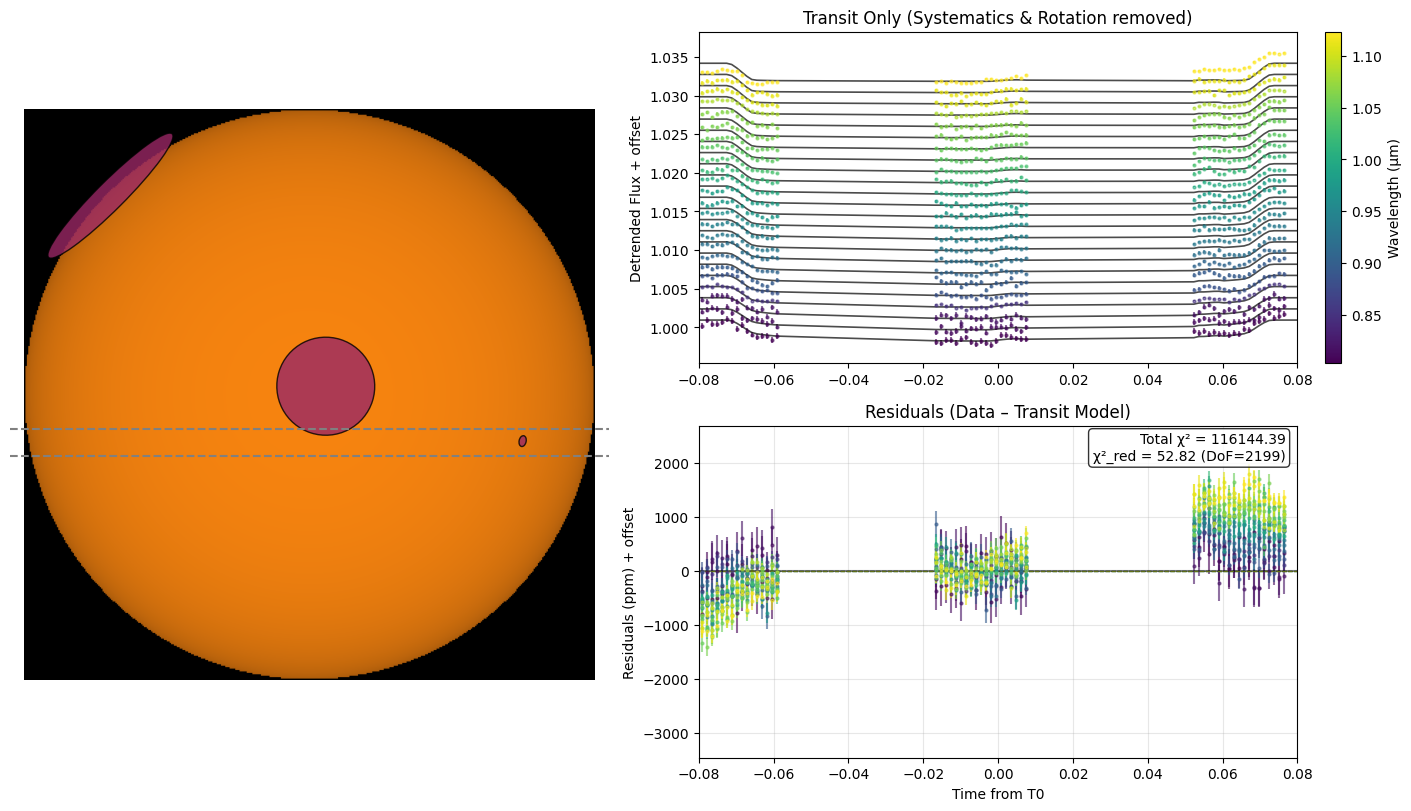

<Figure size 640x480 with 0 Axes>

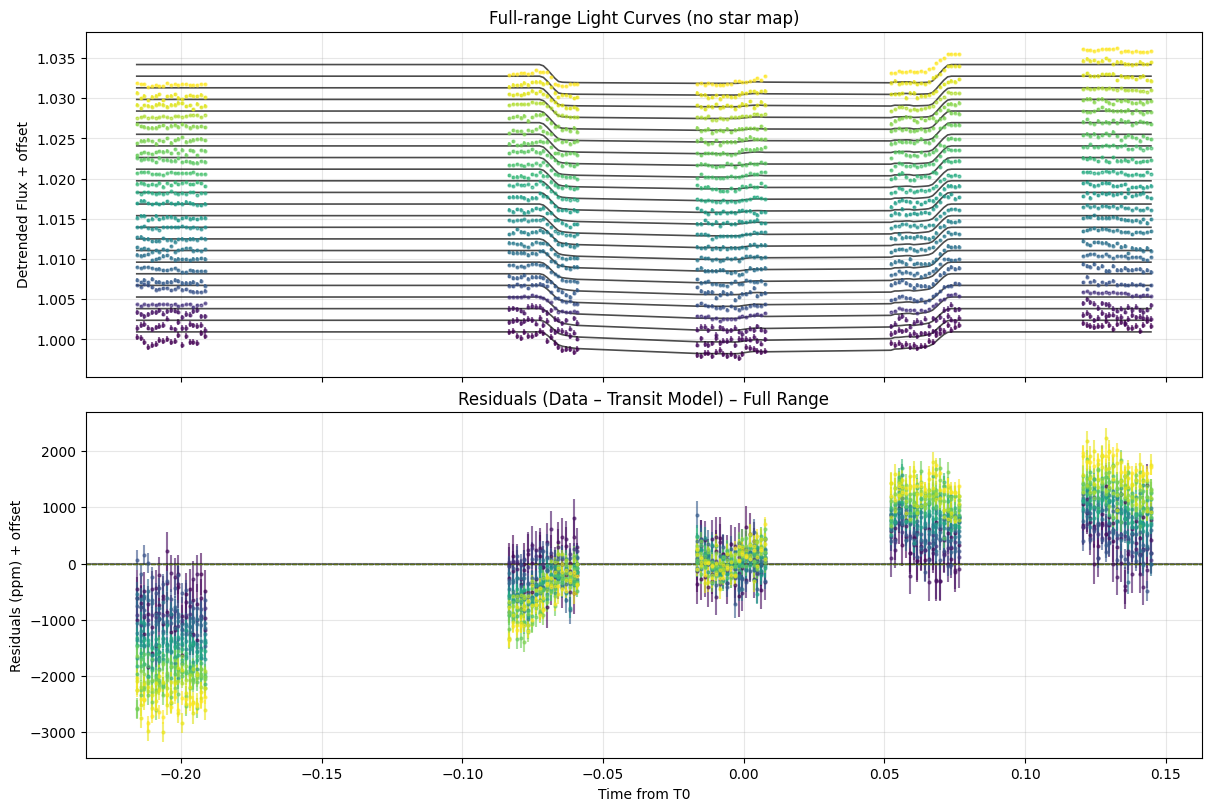

/var/folders/25/jdjk8bs122l32bt2p222l4sh0000gp/T/ipykernel_10651/3187798805.py:331: UserWarning: The figure layout has changed to tight
  fig2.tight_layout()


<Figure size 640x480 with 0 Axes>

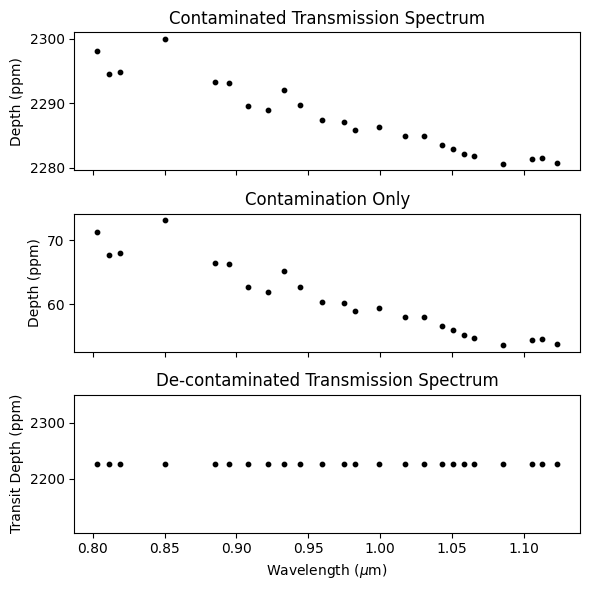

<Figure size 640x480 with 0 Axes>

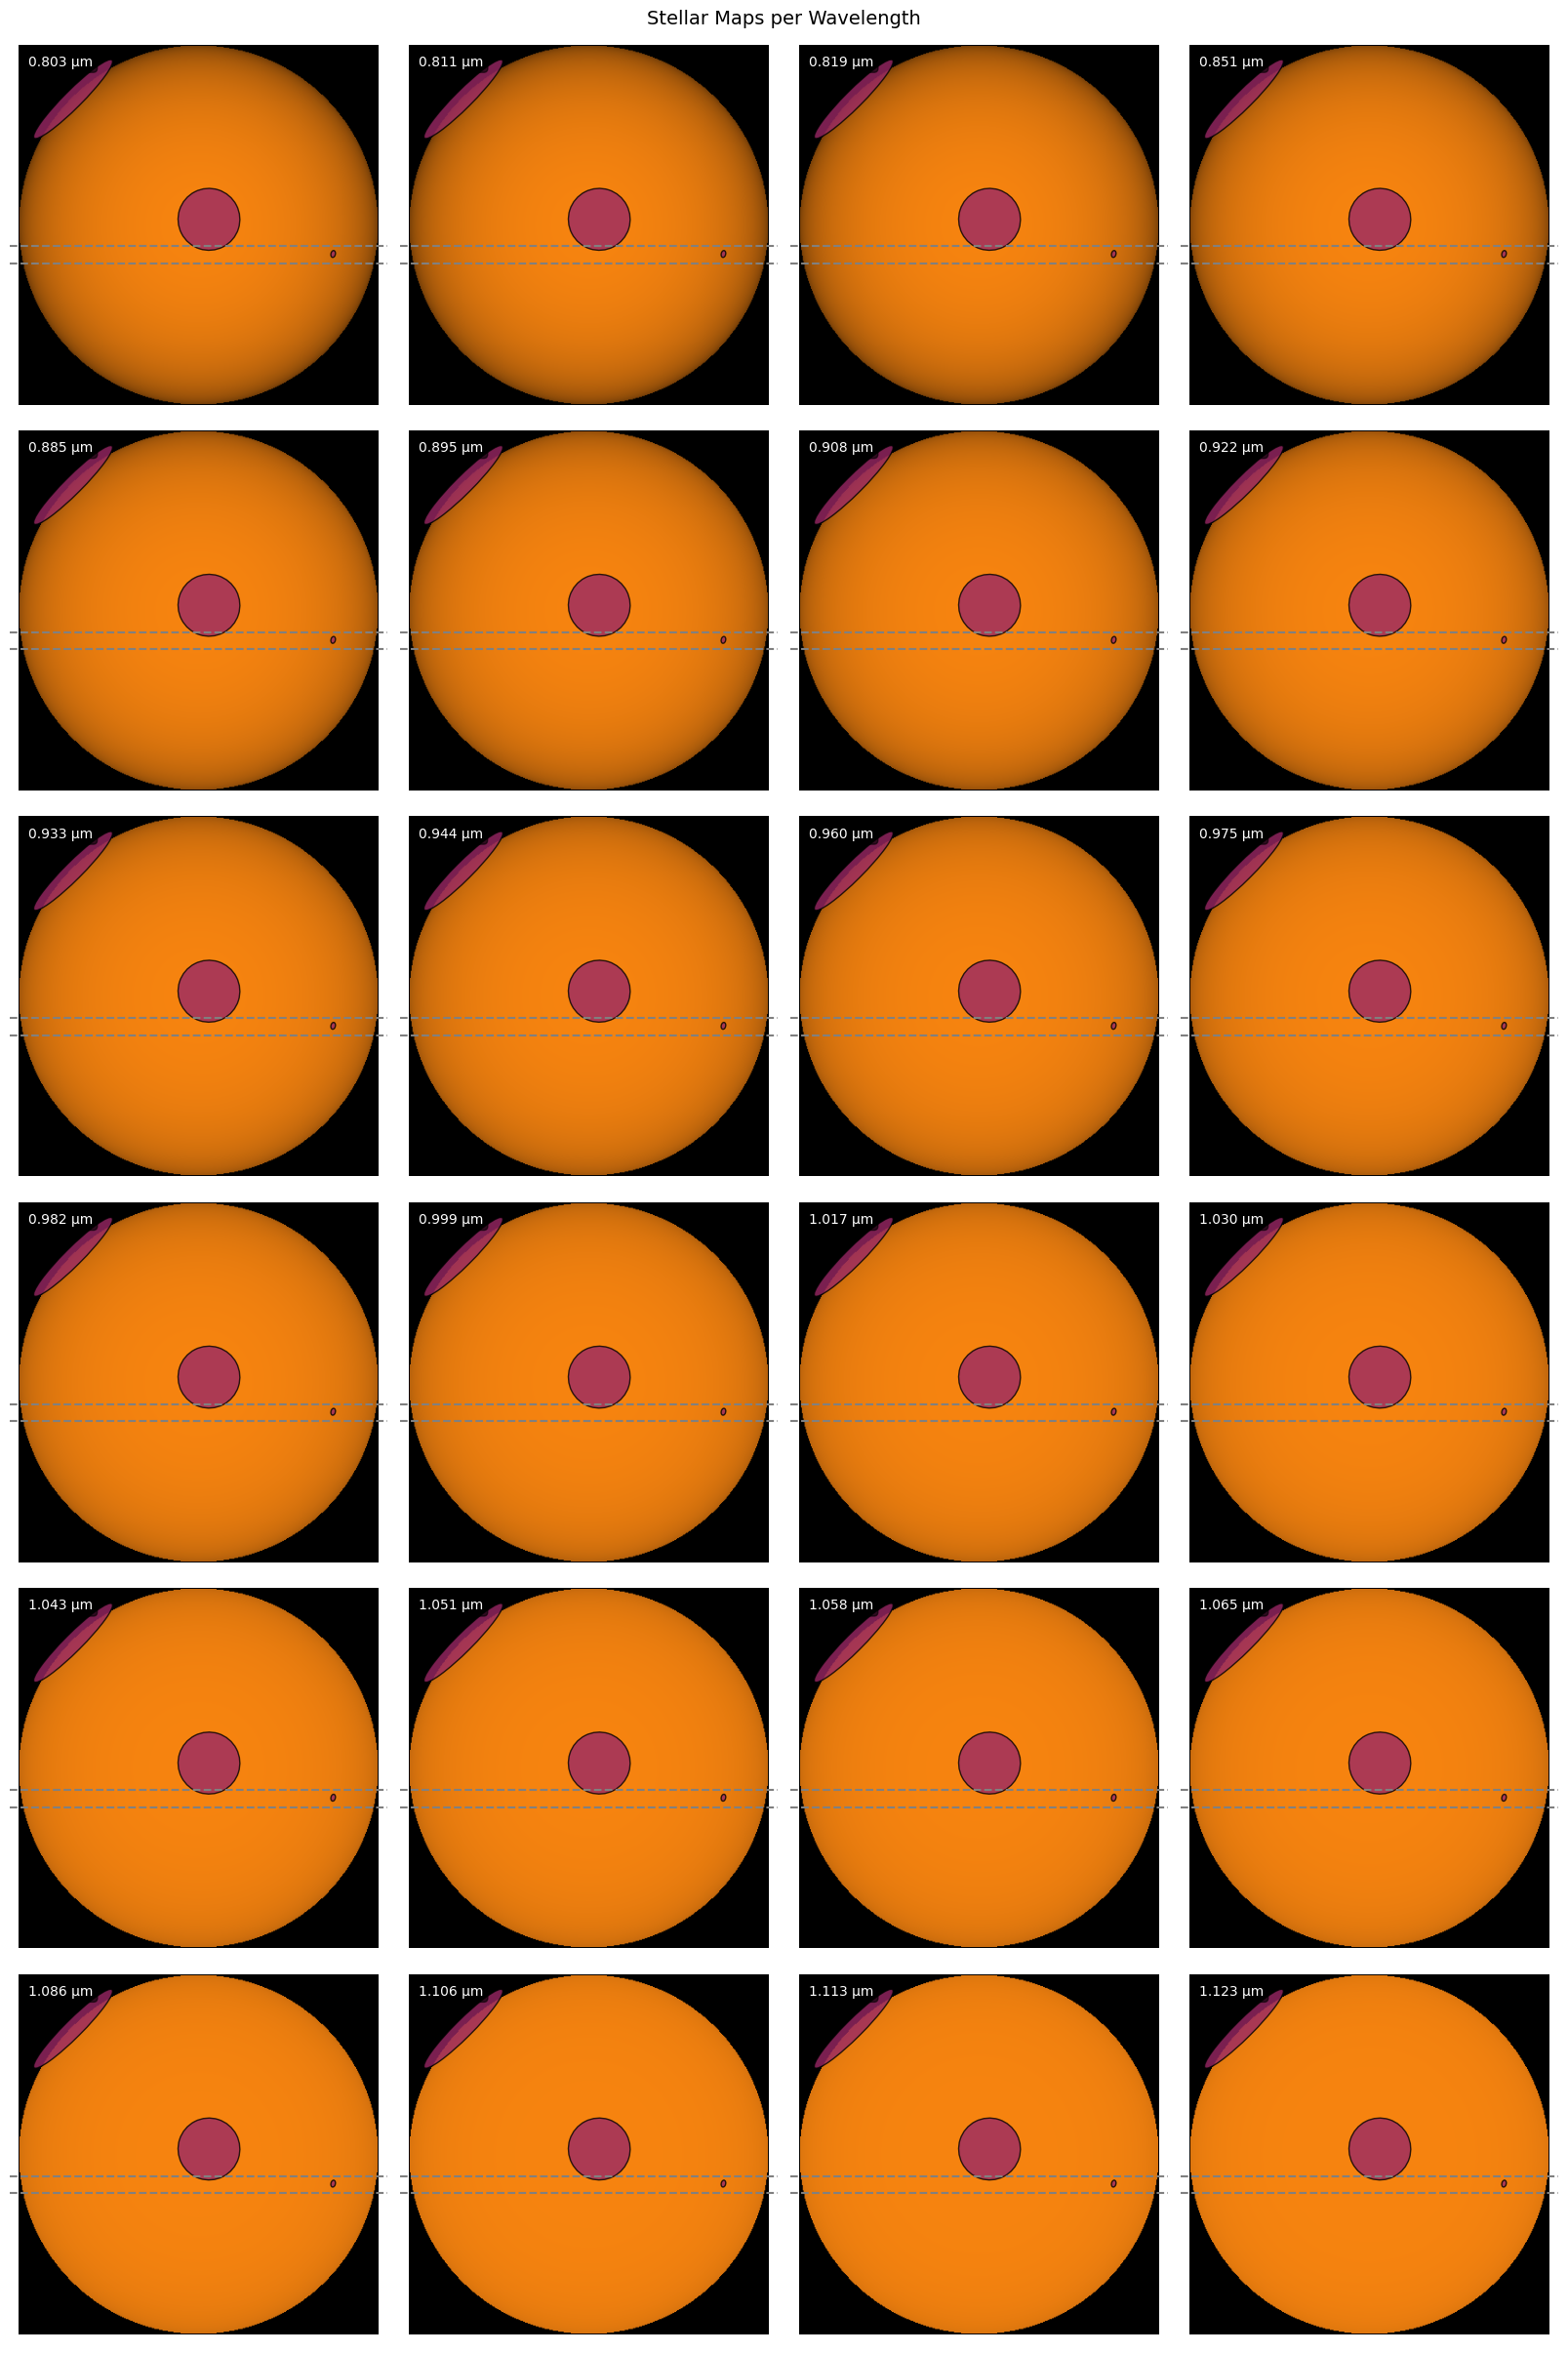

(Array([[1.00782789, 1.0080647 , 1.0082383 , ..., 0.99400251, 0.99395394,
         0.99388772],
        [1.00754481, 1.00778228, 1.00795655, ..., 0.99429199, 0.99424625,
         0.99418285],
        [1.00764561, 1.00788315, 1.0080575 , ..., 0.99421696, 0.99417077,
         0.99410693],
        ...,
        [1.00802911, 1.0082719 , 1.00845143, ..., 0.99436744, 0.99432822,
         0.9942714 ],
        [1.0080796 , 1.00832245, 1.00850204, ..., 0.99433137, 0.99429195,
         0.99423494],
        [1.00803979, 1.0082828 , 1.00846255, ..., 0.99437828, 0.99433939,
         0.9942829 ]], dtype=float64),
 <fleck.jax.ActiveStar at 0x363d99160>)

<Figure size 640x480 with 0 Axes>

In [14]:
# Define parameters (using slopes/intercepts for LD)
params = {
    # Instrument
    'r_1': 4.172413,
    'r_2': -5.063746,
    'r_3': default_params['r_3'],
    'b_1': default_params['b_1'],
    'b_2': -0.238713,
    'b_3': 0.324703,
    'b_4': -0.151913,
    # Spots
    'limb_spot_lon': -1.337244,
    'limb_spot_lat': 0.8,
    'limb_spot_rad': 0.306391,
    'chord_spot_lon_1': 0.057,
    'chord_spot_lat_1': 1.549748,
    'chord_spot_rad_1': 0.172,
    'chord_spot_lon_2': 0.861,
    'chord_spot_lat_2': 1.74,
    'chord_spot_rad_2': 0.019239,
    # Planet
    'rp_rstar': np.array([0.047190] * len(data_wavelengths)),
    't_0': 0.000479,
    'a_rstar': 19.20,
    # Limb darkening
    'u1_slope': -1,
    'u1_intercept': 0.339359,
    'u2_slope': -0.5,
    'u2_intercept': 0.260200,
    # Stellar
    'T_phot': 3891,
    'T_occulted': 3020,
}

model_designation = 'plottingtest'
visit = 'S22'
plot_results(parameter_dict=params, samples=None, figlabel=model_designation)

In [15]:
def post_batch_viz_save(self, **kwargs):
    """
    Tasks to perform after each completed checkpoint.
    """
    print(f'Corner for checkpoint {self.checkpoint}')
    
    # Get samples in chain-major order
    samples_cumulative = self.get_samples()
    
# Create nicely formatted parameter names for titles
    label_map = {
        'r_1': '$r_1$',
        'r_2': '$r_2$', 
        'r_3': '$r_3$',
        'b_1': '$b_1$',
        'b_2': '$b_2$',
        'b_3': '$b_3$',
        'b_4': '$b_4$',
        'a_rstar': '$a/R_*$',
        'rp_rstar': '$R_p/R_*$',
        't_0': '$t_0$',
        'u_1': '$u_1$',
        'u_2': '$u_2$',
        'u1_slope': '$u_1 slope$',
        'u2_slope': '$u_2 slope$',
        'u1_intercept': '$u_1 intercept$',
        'u2_intercept': '$u_2 intercept$',
        'T_phot': '$T_{\\rm phot}$',
        'T_spot': '$T_{\\rm spot}$',
        'T_occulted': '$T_{\\rm occulted}$',
        'T_unocculted': '$T_{\\rm unocculted}$',
        'limb_spot_lon': '$\\theta_{\\rm limb}$',
        'limb_spot_lat': '$\\phi_{\\rm limb}$',
        'limb_spot_rad': '$R_{\\rm limb}$',
        'chord_spot_lon_1': '$\\theta_{\\rm chord,1}$',
        'chord_spot_lat_1': '$\\phi_{\\rm chord,1}$',
        'chord_spot_rad_1': '$R_{\\rm chord,1}$',
        'chord_spot_lon_2': '$\\theta_{\\rm chord,2}$',
        'chord_spot_lat_2': '$\\phi_{\\rm chord,2}$',
        'chord_spot_rad_2': '$R_{\\rm chord,2}$',
        'beta': '$\\beta$'
    }
    
    # EXTRACT MAXIMUM LIKELIHOOD OR CLOSEST-TO-MEDIAN PARAMETERS
    try:
        # Try to get log probability if available
        if hasattr(self, 'get_log_prob'):
            log_prob = self.get_log_prob()
        elif hasattr(self, '_log_prob'):
            log_prob = self._log_prob
        else:
            raise AttributeError("No log probability method found")
            
        # Find max log prob
        if log_prob.ndim > 1:
            flat_log_prob = log_prob.flatten()
            max_idx = jnp.argmax(flat_log_prob)
        else:
            max_idx = jnp.argmax(log_prob)
        
        # Extract ML parameters
        ml_params = {}
        for param_name, param_samples in samples_cumulative.items():
            flattened = param_samples.flatten()
            ml_params[param_name] = float(flattened[max_idx])
        
        print("Maximum likelihood parameters from samples:")
        for param, value in ml_params.items():
            print(f"  {param}: {value:.6f}")
            
    except:
        # Fallback: Find sample closest to median
        print("Using closest-to-median approach for correlated parameters...")
        
        # Compute median for each parameter
        median_params = {}
        for param_name, param_samples in samples_cumulative.items():
            median_params[param_name] = float(jnp.median(param_samples.flatten()))
        
        # Only include sampled parameters (not deterministics or multi-dim)
        # Exclude u_1, u_2 (deterministic arrays) and rp_rstar (multi-dim)
        exclude_from_distance = ['u_1', 'u_2', 'rp_rstar']
        sampled_param_names = [p for p in samples_cumulative.keys() if p not in exclude_from_distance]
        
        # Define n_samples (total number of draws)
        first_param = sampled_param_names[0]
        n_samples = samples_cumulative[first_param].flatten().shape[0]
        
        median_vector = jnp.array([median_params[name] for name in sampled_param_names])
        
        # Build distance only over these parameters
        best_idx = 0
        min_dist = float('inf')
        for idx in range(n_samples):
            sample_vector = jnp.array([samples_cumulative[name].flatten()[idx] for name in sampled_param_names])
            dist = jnp.sum((sample_vector - median_vector)**2)
            if dist < min_dist:
                min_dist = dist
                best_idx = idx
        
        ml_params = {}
        for param_name, param_samples in samples_cumulative.items():
            ml_params[param_name] = float(param_samples.flatten()[best_idx])
        
        print("ML-like parameters (closest to median vector):")
        for param, value in ml_params.items():
            print(f"  {param}: {value:.6f}")

    # ----- Plot results using the extracted parameters -----
    checkpoint_model, checkpoint_star = plot_results(ml_params, samples=samples_cumulative, figlabel=f'chkpt_{self.checkpoint}')
    
    # Compute median and uncertainties for titles (unchanged)
    titles = {}
    for param_name, param_samples in samples_cumulative.items():
        flattened = param_samples.flatten()
        median = jnp.percentile(flattened, 50)
        lower = jnp.percentile(flattened, 16)
        upper = jnp.percentile(flattened, 84)
        sigma_lower = median - lower
        sigma_upper = upper - median
        formatted_name = label_map.get(param_name, param_name)
        titles[param_name] = f"{formatted_name} = {median:.4f}^{{+{sigma_upper:.4f}}}_{{-{sigma_lower:.4f}}}"
    
    labels = [label_map.get(param, param) for param in samples_cumulative.keys()]
    
    # ----- 1. Corner plot: exclude arrays (original) -----
    exclude_corner = ['rp_rstar', 'u_1', 'u_2']
    corner_params = {k: v for k, v in samples_cumulative.items() if k not in exclude_corner}
    corner_titles = {k: titles[k] for k in corner_params.keys()}
    corner_labels = [label_map.get(k, k) for k in corner_params.keys()]
    
    corner.corner(corner_params, 
                  quantiles=[0.16, 0.50, 0.84],
                  titles=corner_titles,
                  labels=corner_labels,
                  title_kwargs={"fontsize": 11},
                  show_titles=True)
    plt.suptitle(f'checkpoint {self.checkpoint}')
    plt.savefig(f'../../figs/{visit}_chkpt_{self.checkpoint}_corner_excl_arrays.png', dpi=400)
    plt.show()
    plt.clf()

    # ----- 2. Histogram figure for rp, u1, u2 at all wavelengths -----
    # Extract arrays: shape (n_samples, n_wavelengths)
    if 'rp_rstar' in samples_cumulative:
        rp_samples = samples_cumulative['rp_rstar'].reshape(-1, len(data_wavelengths))
    else:
        rp_samples = None
    
    if 'u_1' in samples_cumulative:
        u1_samples = samples_cumulative['u_1'].reshape(-1, len(data_wavelengths))
    else:
        u1_samples = None
    
    if 'u_2' in samples_cumulative:
        u2_samples = samples_cumulative['u_2'].reshape(-1, len(data_wavelengths))
    else:
        u2_samples = None
    
    # Only proceed if at least one of them exists
    if any(x is not None for x in [rp_samples, u1_samples, u2_samples]):
        # Prepare colormap
        wavelengths = np.asarray(data_wavelengths)
        norm = mcolors.Normalize(vmin=wavelengths.min(), vmax=wavelengths.max())
        cmap = plt.cm.viridis
        
        # Create figure with 3 rows (one for each parameter)
        fig_hists, axes = plt.subplots(3, 1, figsize=(8, 12), sharex=False)
        params_to_plot = [
            ('rp_rstar', rp_samples, axes[0], r'$R_p/R_*$'),
            ('u_1', u1_samples, axes[1], r'$u_1$'),
            ('u_2', u2_samples, axes[2], r'$u_2$')
        ]
        
        for param_name, samples, ax, xlabel in params_to_plot:
            if samples is None:
                ax.text(0.5, 0.5, f'{param_name} not available', ha='center', va='center', transform=ax.transAxes)
                ax.set_title(f'{param_name} (missing)')
                continue
            
            n_wl = samples.shape[1]
            # Plot histograms for each wavelength with transparency
            for i, wl in enumerate(wavelengths):
                color = cmap(norm(wl))
                # Compute histogram
                hist, bins = np.histogram(samples[:, i], bins=30, density=True)
                bin_centers = (bins[:-1] + bins[1:]) / 2
                # Plot as filled area or step? We'll use fill_between for a smooth look.
                ax.fill_between(bin_centers, 0, hist, color=color, alpha=0.3, step='mid')
                # Or use step plot: ax.step(bin_centers, hist, where='mid', color=color, alpha=0.7)
                # For visibility, we can also plot median vertical lines per wavelength
                med = np.median(samples[:, i])
                low = np.percentile(samples[:, i], 16)
                high = np.percentile(samples[:, i], 84)
                ax.axvline(med, color=color, linestyle='-', linewidth=1.5, alpha=0.8)
                ax.axvline(low, color=color, linestyle='--', linewidth=0.8, alpha=0.5)
                ax.axvline(high, color=color, linestyle='--', linewidth=0.8, alpha=0.5)
            
            ax.set_xlabel(xlabel)
            ax.set_ylabel('Density')
            ax.set_title(f'{param_name} distributions per wavelength')
            ax.grid(alpha=0.3)
        
        # Add a colorbar to indicate wavelength
        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        cbar = fig_hists.colorbar(sm, ax=axes, orientation='horizontal', pad=0.05, aspect=30)
        cbar.set_label('Wavelength (µm)')
        
        fig_hists.suptitle(f'checkpoint {self.checkpoint} – Marginal distributions of rp, u1, u2', fontsize=14)
        plt.savefig(f'../../figs/{visit}_chkpt_{self.checkpoint}_histograms_rp_u1_u2.png', dpi=400)
        plt.show()
        plt.clf()
    else:
        print("No wavelength‑dependent parameters (rp, u1, u2) found – skipping histogram figure.")

    # Save cumulative samples
    with open(f'../../data/samples/samples_cumulative_{self.start_time}_checkpoint_{self.checkpoint:04d}.pkl', 'wb') as file:
        pickle.dump(dict(samples_cumulative), file)

In [16]:
rng_seed = 0

def hstack_recursive(final_states, checkpoint_states):
    for key in final_states.keys():
        if isinstance(final_states[key], dict):
            hstack_recursive(final_states[key], checkpoint_states[key])
        else:
            final_states[key] = jnp.hstack([
                final_states[key], 
                checkpoint_states[key]
            ])

def print_big_message(big_message):
    print('\n\n')
    print('=' * len(big_message))
    print(big_message)
    print('=' * len(big_message))
    print('\n\n')

class MCMCWithCheckpoints(MCMC):
    running_states = None
    checkpoint = 0
    start_time = None
    
    def run_checkpoints(self, rng_key, *args, extra_fields=(), n_checkpoints=10, 
                        progress_bar_warmup=True, progress_bar_samples=True, 
                        init_params=None, on_checkpoint=None, **kwargs):
        """
        Run the MCMC samplers and collect samples.

        :param random.PRNGKey rng_key: Random number generator key to be used for the sampling.
            For multi-chains, a batch of `num_chains` keys can be supplied. If `rng_key`
            does not have batch_size, it will be split in to a batch of `num_chains` keys.
        :param args: Arguments to be provided to the :meth:`numpyro.infer.mcmc.MCMCKernel.init` method.
            These are typically the arguments needed by the `model`.
        :param extra_fields: Extra fields (aside from `"z"`, `"diverging"`) from the
            state object (e.g. :data:`numpyro.infer.hmc.HMCState` for HMC) to be collected
            during the MCMC run. Note that subfields can be accessed using dots, e.g.
            `"adapt_state.step_size"` can be used to collect step sizes at each step. Exclude sample sites from
            collection with "~`sampler.sample_field`.`sample_site`". e.g. "~z.a" will prevent site "a" from
            being collected if you're using the NUTS sampler. To collect samples of a site "a" in the
            unconstrained space, we can specify the variable here, e.g. `extra_fields=("z.a",)`.
        :type extra_fields: tuple or list of str
        :param init_params: Initial parameters to begin sampling. The type must be consistent
            with the input type to `potential_fn` provided to the kernel. If the kernel is
            instantiated by a numpyro model, the initial parameters here correspond to latent
            values in unconstrained space.
        :param kwargs: Keyword arguments to be provided to the :meth:`numpyro.infer.mcmc.MCMCKernel.init`
            method. These are typically the keyword arguments needed by the `model`.

        .. note:: jax allows python code to continue even when the compiled code has not finished yet.
            This can cause troubles when trying to profile the code for speed.
            See https://jax.readthedocs.io/en/latest/async_dispatch.html and
            https://jax.readthedocs.io/en/latest/profiling.html for pointers on profiling jax programs.
        """
        self.start_time = datetime.now().strftime("%Y-%m-%d_%H-%M")
        num_warmup_total = int(self.num_warmup)
        num_samples_total = int(self.num_samples)
        
        check_point_indices = [
            jnp.arange(num_warmup_total), 
            *jnp.array_split(jnp.arange(num_samples_total), n_checkpoints)
        ]
        n_checkpoints = len(check_point_indices)
        rng_keys = random.split(rng_key, n_checkpoints)
        pbar = tqdm(enumerate(zip(rng_keys, check_point_indices)), total=n_checkpoints)
        for checkpoint, (rng_key, bounds) in pbar:
            if checkpoint == 0:
                self.progress_bar = progress_bar_warmup
                pbar.set_description('Run warmup')
                print_big_message("Begin warmup")
                self.warmup(rng_key, *args, extra_fields=extra_fields, init_params=init_params, **kwargs)
                print_big_message(f"Begin {num_samples_total} samples with {n_checkpoints} checkpoints")

            else:
                pbar.set_description(f'Run samples {bounds.min()} to {bounds.max()}')

                self.progress_bar = progress_bar_samples
                self.num_samples = bounds.size
                self.run(rng_key, *args, extra_fields=extra_fields, init_params=init_params, **kwargs)

                # add to running states:
                if self.running_states is None:
                    self.running_states = dict(self._states)
                else:
                    hstack_recursive(self.running_states, self._states)
                
                # ensure that calls to `self.get_samples` will build a new samples array
                # out of the running states:
                self._states_flat = None
                self._states = self.running_states

                if on_checkpoint is not None:
                    on_checkpoint(self, **kwargs)
                self.checkpoint += 1
        
        pbar.close()

        # reset to total number for arviz IO
        self.num_samples = num_samples_total

In [ ]:
n_warmup = 2_000
n_samples = 20_000
n_chains = 12
n_checks = 10
current_date = datetime.now().strftime("%Y_%m_%d")

model_designation = f'{visit}_{n_samples}samples_{n_chains}chains_{current_date}_specLC_fixedTphot'

rng_key = PRNGKey(22)

sampler = NUTS(
    numpyro_model,
    dense_mass=True
    )

mcmc = MCMCWithCheckpoints(
    sampler, 
    num_warmup=n_warmup, 
    num_samples=n_samples,
    num_chains=n_chains
)

mcmc.run_checkpoints(rng_key, n_checkpoints=n_checks, on_checkpoint=post_batch_viz_save)

mcmc.print_summary()                                                                        

# arviz converts a numpyro MCMC object to an `InferenceData` object based on xarray:
result = arviz.from_numpyro(mcmc)

median_params = arviz.summary(result,stat_focus='median')
print(median_params)
'Save the result'
result.to_netcdf(f'../../data/samples/{model_designation}')
'Print the summary'
arviz.summary(result)

'Make a corner plot'
corner.corner(
    result,
)
plt.savefig(f'../../figs/{model_designation}_corner.png',dpi=200)

'Examine the Leave-One-Out (LOO) summary'
loo = arviz.loo(result, pointwise=True)
loo

  0%|          | 0/11 [00:00<?, ?it/s]




Begin warmup





  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

...

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

Corner for checkpoint 0


In [ ]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import arviz as az

def calculate_model(parameter_dict, relative_flux, lc_index):
    """
    Compute the transit model for a given wavelength index and return
    normalized model, residuals, detrended model, and detrended data.
    
    Parameters
    ----------
    parameter_dict : dict
        Parameter values (MAP or draw). Must contain all required parameters.
    relative_flux : array
        Observed flux for the specific wavelength (1D, length n_times).
    lc_index : int
        Index of the wavelength in the multi-wavelength array.
    
    Returns
    -------
    normalized_model : array
        Model including systematics, normalized to mean=1.
    residuals : array
        relative_flux - normalized_model.
    de_trended_model : array
        Model with systematics divided out, normalized to mean=1.
    de_trended_data : array
        Data with systematics divided out, normalized to mean=1.
    """
    params = parameter_dict

    # ----- 1. Systematics (achromatic) -----
    ramp = ramp_model_jax(phase=ramp_phase,
                          r1=jnp.asarray(params.get('r_1', default_params['r_1']), dtype=jnp.float64),
                          r2=jnp.asarray(params.get('r_2', default_params['r_2']), dtype=jnp.float64),
                          r3=jnp.asarray(params.get('r_3', default_params['r_3']), dtype=jnp.float64))
    breathing = breathing_model_jax(phase=breathing_phase,
                                    b1=jnp.asarray(params.get('b_1', default_params['b_1']), dtype=jnp.float64),
                                    b2=jnp.asarray(params.get('b_2', default_params['b_2']), dtype=jnp.float64),
                                    b3=jnp.asarray(params.get('b_3', default_params['b_3']), dtype=jnp.float64),
                                    b4=jnp.asarray(params.get('b_4', default_params['b_4']), dtype=jnp.float64))
    _systematics = breathing * ramp
    systematics = _systematics / jnp.mean(_systematics)

    # ----- 2. Limb‑darkening coefficients (per wavelength) -----
    if 'u1_slope' in params and 'u1_intercept' in params:
        u1 = params['u1_slope'] * (data_wavelengths - data_wavelengths[0]) + params['u1_intercept']
        u2 = params['u2_slope'] * (data_wavelengths - data_wavelengths[0]) + params['u2_intercept']
    else:
        # Fallback to direct u_1, u_2 (could be arrays or scalars)
        u1 = params.get('u_1', default_params['u_1'])
        u2 = params.get('u_2', default_params['u_2'])

    # ----- 3. Planet parameters -----
    planet_parameters = {
        'inclination': jnp.radians(default_params['i_planet']),
        'a': jnp.asarray(params.get('a_rstar', default_params['a_rstar']), dtype=jnp.float64),
        'rp': jnp.asarray(params.get('rp_rstar', default_params['rp_rstar']), dtype=jnp.float64),
        'period': jnp.asarray(params.get('P_orb', default_params['P_orb']), dtype=jnp.float64),
        't0': jnp.asarray(params.get('t_0', default_params['t_0']), dtype=jnp.float64),
        'ecc': jnp.asarray(params.get('ecc', default_params['ecc']), dtype=jnp.float64),
        'u1': jnp.asarray(u1, dtype=jnp.float64),
        'u2': jnp.asarray(u2, dtype=jnp.float64),
    }

    # ----- 4. Spectra and active star -----
    T_phot = params.get('T_phot', default_params['T_phot'])
    # Try T_occulted first, fallback to T_spot for backward compatibility
    T_occulted = params.get('T_occulted', params.get('T_spot', default_params.get('T_spot', 3000)))

    Phot = get_BTSettl_spectrum_jax(T=jnp.asarray(T_phot, dtype=jnp.float64),metallicity=0,
                                           data_wave=data_wavelengths)
    Cool = get_BTSettl_spectrum_jax(T=jnp.asarray(T_occulted, dtype=jnp.float64),metallicity=0,
                                           data_wave=data_wavelengths)

    active_star = ActiveStar(
        times=time_from_T0,
        inclination=jnp.radians(default_params['i_star']),
        T_eff=jnp.asarray(T_phot, dtype=jnp.float64),
        wavelength=Phot[0] * 1e-6,          # µm → m
        phot=Phot[1],
        P_rot=default_params['P_rot']
    )

    # Three spots: limb, chord1, chord2 (order matches the model)
    active_star.spectrum = jnp.vstack([Cool[1]] * 3)
    active_star.temperature = jnp.array([T_occulted] * 3)
    active_star.lon = jnp.array([
        params.get('limb_spot_lon', default_params['limb_spot_lon']),
        params.get('chord_spot_lon_1', default_params['chord_spot_lon_1']),
        params.get('chord_spot_lon_2', default_params['chord_spot_lon_2'])
    ])
    active_star.lat = jnp.array([
        params.get('limb_spot_lat', default_params['limb_spot_lat']),
        params.get('chord_spot_lat_1', default_params['chord_spot_lat_1']),
        params.get('chord_spot_lat_2', default_params['chord_spot_lat_2'])
    ])
    active_star.rad = jnp.array([
        params.get('limb_spot_rad', default_params['limb_spot_rad']),
        params.get('chord_spot_rad_1', default_params['chord_spot_rad_1']),
        params.get('chord_spot_rad_2', default_params['chord_spot_rad_2'])
    ])

    # ----- 5. Transit model -----
    lc, contam, X, Y, spectrum_at_transit = active_star.transit_model(**planet_parameters)
    # lc shape: (n_times, n_wavelengths)
    lc_model = lc.T[lc_index] * systematics          # (n_times,)
    mean_per_wavelength = jnp.mean(lc_model)
    normalized_model = lc_model / mean_per_wavelength

    residuals = relative_flux - normalized_model
    de_trended_model = normalized_model / systematics
    de_trended_data = relative_flux / systematics

    return (normalized_model, residuals,
            de_trended_model / jnp.mean(de_trended_model),
            de_trended_data / jnp.mean(de_trended_data))


def get_representative_sample_from_dict(posterior_dict_entry, method='median'):
    """
    Extract a single representative sample from an ArviZ posterior dataset.
    The sample chosen is the one closest to the medians of all parameters.

    Parameters
    ----------
    posterior_dict_entry : xarray.Dataset
        The posterior dataset (e.g., `result.posterior`).
    method : str
        Currently only 'median' is supported.

    Returns
    -------
    dict
        Parameter names and their values for the representative sample.
    """
    posterior_dataset = posterior_dict_entry
    medians = posterior_dataset.median()
    param_names = list(posterior_dataset.data_vars)

    all_samples = []
    median_values = []
    for param in param_names:
        samples = posterior_dataset[param].values.flatten()
        all_samples.append(samples)
        median_values.append(float(medians[param]))

    param_matrix = np.column_stack(all_samples)          # (n_samples, n_params)
    median_array = np.array(median_values)               # (n_params,)

    distances = np.linalg.norm(param_matrix - median_array, axis=1)
    closest_idx = np.argmin(distances)

    representative_params = {}
    for i, param in enumerate(param_names):
        representative_params[param] = param_matrix[closest_idx, i]

    return representative_params


def plot_mosaic_lightcurves(data_wavelengths, jax_flux, jax_rel_err, time_from_T0,
                            posterior_samples_dict, model_designation_base,
                            cmap_name='inferno_r', vertical_spacing=0.01):
    """
    Create a stacked mosaic of detrended light curves and residuals for all wavelengths.

    Parameters
    ----------
    data_wavelengths : array
        Wavelength values for each light curve.
    jax_flux : 2D array
        Flux values, shape (n_lc, n_times).
    jax_rel_err : 2D array
        Uncertainties, shape (n_lc, n_times).
    time_from_T0 : array
        Time array.
    posterior_samples_dict : dict
        Dictionary mapping index -> ArviZ posterior dataset.
    model_designation_base : str
        Base name for saving the figure.
    cmap_name : str
        Matplotlib colormap name.
    vertical_spacing : float
        Vertical offset between adjacent light curves.

    Returns
    -------
    fig, (ax_lc, ax_res)
    """
    n_lc = len(data_wavelengths)
    sorted_indices = np.argsort(data_wavelengths)       # shortest to longest

    cmap = plt.get_cmap(cmap_name)
    colors = [cmap(i / (n_lc - 1)) for i in range(n_lc)]

    fig, (ax_lc, ax_res) = plt.subplots(1, 2, figsize=(9, 8), sharey=False)
    plt.subplots_adjust(wspace=0.05)

    x_mid = (time_from_T0.min() + time_from_T0.max()) / 2

    for plot_idx, lc_idx in enumerate(sorted_indices):
        relative_flux = jax_flux[lc_idx, :]
        data_unc = jax_rel_err[lc_idx, :]
        wavelength = data_wavelengths[lc_idx]
        color = colors[lc_idx]

        offset = plot_idx * vertical_spacing

        # Get representative sample and compute model
        param_medians = get_representative_sample_from_dict(posterior_samples_dict[lc_idx])
        _, residuals, median_model, detrended_relative_flux = calculate_model(
            param_medians, relative_flux, lc_idx
        )

        # ---- Left panel: light curves ----
        ax_lc.errorbar(time_from_T0, detrended_relative_flux - offset - 0.00025,
                       yerr=data_unc, fmt='o', ms=2,
                       color=color, alpha=0.7, markeredgecolor='k', markeredgewidth=0.5)
        ax_lc.plot(time_from_T0, median_model - offset - 0.00025,
                   '-', color='k', linewidth=1.5, alpha=0.8)

        # Wavelength label
        ax_lc.text(x_mid - 0.07, detrended_relative_flux.mean() - 0.0012 - offset,
                   f'{wavelength:.3f} µm', fontsize=9, color='k',
                   ha='center', va='center',
                   bbox=dict(boxstyle='round,pad=0.2', facecolor='none', edgecolor='none'))

        # Median uncertainty label
        if lc_idx == 0:
            label = r'$\rm \tilde{\sigma}_{obs}$=' + f'{int(np.median(data_unc)*1e6)} ppm'
            xpos = x_mid
        else:
            label = f'{int(np.median(data_unc)*1e6)} ppm'
            xpos = x_mid + 0.0075
        ax_lc.text(xpos, detrended_relative_flux.mean() - 0.0012 - offset,
                   label, fontsize=9, color='k',
                   ha='center', va='center',
                   bbox=dict(boxstyle='round,pad=0.2', facecolor='none', edgecolor='none'))

        # ---- Right panel: residuals ----
        ax_res.errorbar(time_from_T0, residuals - offset,
                        yerr=data_unc, fmt='o', ms=2,
                        color=color, alpha=0.7, markeredgecolor='k', markeredgewidth=0.5)

        rchisquare = jnp.sum((residuals**2) / (data_unc**2)) / (len(data_unc) - 6)
        if lc_idx == 0:
            label = r'$\rm r\chi^2 = $' + f'{rchisquare:.2f}'
            xpos = x_mid
        else:
            label = f'{rchisquare:.2f}'
            xpos = x_mid + 0.0075
        ax_res.text(xpos, residuals.mean() - offset,
                    label, fontsize=9, color='k',
                    ha='center', va='center',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none'))

        ax_res.axhline(y=0 - offset, color='k', linestyle='--', alpha=0.5, linewidth=1)

    # Axis limits and labels
    ax_lc.set_xlim(-0.09, 0.09)
    ax_res.set_xlim(-0.09, 0.09)
    ax_lc.set_ylim(0.956, 1.00215)
    ax_res.set_ylim(-0.0448, 0.0014)

    ax_lc.set_ylabel('Relative Flux (offset)', fontsize=12)
    ax_lc.set_xlabel('Time from T0', fontsize=12)

    ax_res.set_ylabel('')                         # hide right ylabel
    ax_res.set_xlabel('Time from T0 (d)', fontsize=12)
    ax_res.set_yticklabels([])
    ax_res.yaxis.set_ticks_position('none')
    ax_res.tick_params(axis='y', which='both', length=0)

    ax_lc.set_title('De-Trended Light Curves')
    ax_res.set_title('Median Fit Residuals')

    fig.tight_layout(pad=1.0)
    plt.subplots_adjust(wspace=0.0)

    plt.savefig(f'../../figs/{model_designation_base}_mosaic.png', dpi=400, bbox_inches='tight')
    plt.show()

    return fig, (ax_lc, ax_res)

In [ ]:
plt.figure()
plt.xlabel('Wavelength (micron)')
plt.ylabel('Transit Depth (Rp/R*)^2')

for lc_index in [0,1,2,3,4,5,6,7,
                8,9,10,11,12,13,
                 14,15,16,17,18,
                19,20,21,22,23]:

    model_designation = f'{visit}_{n_samples}samples_{n_chains}chains_lc{lc_index}_{current_date}_transitonly_fixedr'
    data_unc = jax_rel_err[lc_index,:]
    relative_flux =  jax_flux[lc_index,:]

    result = arviz.InferenceData.from_netcdf(f'../../data/samples/{model_designation}')

    # Extract posterior samples
    posterior = result.posterior
    
    # Print median and standard deviation for all parameters with high precision
    # print(f"\n=== Results for lc_index {lc_index} ===")
    
    # Calculate median and std for all parameters
    param_medians = posterior.median()
    param_stds = posterior.std()
    
    # Print each parameter with the required precision
    # for var_name in posterior.data_vars:
    median_val = float(param_medians['rp_rstar'].values)
    std_val = float(param_stds['rp_rstar'].values)
    print(f"{data_wavelengths[lc_index]:.5f} {speclc_bin_edges.value[lc_index]:.5f} {speclc_bin_edges.value[lc_index+1]:.5f} {median_val:.5f} {std_val:.6f}")
    rel_err = std_val/median_val
    
    plt.errorbar(data_wavelengths[lc_index], median_val**2, yerr=rel_err * median_val**2,fmt='o',color='k')


plt.savefig(f'../../figs/{model_designation}_transmissionspec.png')

In [ ]:
# Collect all data first to ensure consistent headers
all_data = []

for lc_index in [0,1,2,3,4,5,6,7,
                8,9,10,11,12,13,
                 14,15,16,17,18,
                19,20,21,22,23]:

    model_designation = f'{visit}_{n_samples}samples_{n_chains}chains_lc{lc_index}_{current_date}_transitonly_fixedr'
    data_unc = jax_rel_err[lc_index,:]
    relative_flux =  jax_flux[lc_index,:]

    result = arviz.InferenceData.from_netcdf(f'../../data/samples/{model_designation}')
    
    # Extract posterior samples
    posterior = result.posterior
    
    # Calculate median and std for all parameters
    param_medians = posterior.median()
    param_stds = posterior.std()
    
    # Store data for this lc_index
    data_entry = {
        'wavelength': data_wavelengths[lc_index],
        'bin_low': speclc_bin_edges.value[lc_index],
        'bin_high': speclc_bin_edges.value[lc_index+1],
        'params': {}
    }
    
    for var_name in posterior.data_vars:
        data_entry['params'][var_name] = {
            'median': float(param_medians[var_name].values),
            'std': float(param_stds[var_name].values)
        }
    
    all_data.append(data_entry)

# Print headers (get param names from first entry)
if all_data:
    param_names = list(all_data[0]['params'].keys())
    
    # Print header
    header = f"{'wavelength':<12} {'bin_low':<12} {'bin_high':<12}"
    for param in param_names:
        header += f" {param}_median {param}_std"
    print(header)
    
    # Print data rows
    for data in all_data:
        row = f"{data['wavelength']:<12.5f} {data['bin_low']:<12.5f} {data['bin_high']:<12.5f}"
        for param in param_names:
            median_val = data['params'][param]['median']
            std_val = data['params'][param]['std']
            row += f" {median_val:.5f} {std_val:.6f}"
        print(row)